# Day 1 - 배터리 데이터 로드

`archive/`의 `.mat` 파일(MATLAB v7.3 = HDF5)을 `h5py`로 읽습니다.

- `summary`: 셀별 cycle 단위 요약값 (IR, QDischarge, Tavg, chargetime 등) → 가볍고 빠름
- `cycles`: cycle 내부 시계열 (V, I, T, Qd, Qdlin 등) → 무거우므로 필요한 셀만 따로 로드

In [1]:
from pathlib import Path

import h5py
import numpy as np
import pandas as pd

DATA_DIR = Path("../archive")   # 원본 .mat은 저장소 루트의 archive/
mat_files = sorted(DATA_DIR.glob("*.mat"))
for p in mat_files:
    print(f"{p.name}  ({p.stat().st_size / 1e9:.2f} GB)")

2017-05-12_batchdata_updated_struct_errorcorrect.mat  (3.03 GB)
2018-02-20_batchdata_updated_struct_errorcorrect.mat  (2.02 GB)
2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat  (0.09 GB)
2018-04-12_batchdata_updated_struct_errorcorrect.mat  (3.24 GB)


## Batch 1 (2017-05-12) → `batch1` DataFrame

셀별 `summary`를 (cell_id, cycle) 단위 long format으로 합칩니다.

In [2]:
def mat_str(f, ref):
    """MATLAB char 배열(uint16) → str"""
    return "".join(chr(c) for c in f[ref][()].ravel())


def load_summary_df(path):
    dfs = []
    with h5py.File(path, "r") as f:
        batch = f["batch"]
        for i in range(batch["summary"].shape[0]):
            summary = f[batch["summary"][i, 0]]
            df = pd.DataFrame({k: summary[k][()].ravel() for k in summary.keys()})
            df.insert(0, "cell_id", i)
            df.insert(1, "policy", mat_str(f, batch["policy_readable"][i, 0]))
            df.insert(2, "cycle_life", f[batch["cycle_life"][i, 0]][()].item())
            dfs.append(df)
    return pd.concat(dfs, ignore_index=True)


batch1 = load_summary_df(DATA_DIR / "2017-05-12_batchdata_updated_struct_errorcorrect.mat")
print(batch1.shape, "| cells:", batch1["cell_id"].nunique())
batch1.head()

(38811, 11) | cells: 46


,cell_id,policy,cycle_life,IR,QCharge,QDischarge,Tavg,Tmax,Tmin,chargetime,cycle
0,0,3.6C(80%)-3.6C,1190.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
1,0,3.6C(80%)-3.6C,1190.0,0.016742,1.071042,1.070689,31.875011,35.652016,29.566130,13.341250,2.0
2,0,3.6C(80%)-3.6C,1190.0,0.016724,1.071674,1.071900,31.931490,35.692978,29.604385,13.425777,3.0
3,0,3.6C(80%)-3.6C,1190.0,0.016681,1.072304,1.072510,31.932603,35.680588,29.744202,13.425167,4.0
4,0,3.6C(80%)-3.6C,1190.0,0.016662,1.072970,1.073174,31.959322,35.728691,29.644709,13.341442,5.0


## Batch 2 (2018-02-20), Batch 3 (2018-04-12)

In [3]:
batch2 = load_summary_df(DATA_DIR / "2018-02-20_batchdata_updated_struct_errorcorrect.mat")
batch3 = load_summary_df(DATA_DIR / "2018-04-12_batchdata_updated_struct_errorcorrect.mat")

for name, df in [("batch2", batch2), ("batch3", batch3)]:
    print(f"{name}: {df.shape} | cells: {df['cell_id'].nunique()}")

batch2: (26904, 11) | cells: 47
batch3: (51007, 11) | cells: 46


# EDA 1. Cycle Life 분포는 어떻게 생겼는가?

- 150 ~ 2,300 사이클 Histogram
- 장수명(>1,000) / 단수명(<500) 비율 확인
- 이상치 셀 식별 - 왜 유독 짧은가?

배치별로 따로 봅니다.

In [4]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

SHORT, LONG = 500, 1000
BINS = np.arange(150, 2350, 50)


def cell_table(df):
    """(cell, cycle) long df → 셀 단위 요약 테이블"""
    return df.groupby("cell_id").agg(
        policy=("policy", "first"),
        cycle_life=("cycle_life", "first"),
        n_cycles=("cycle", "max"),
        Q_init=("QDischarge", lambda s: s.iloc[1:11].median()),  # 사이클 1은 0값이 섞여 있어 제외
        Q_last=("QDischarge", "last"),
    )


def eda_cycle_life(df, name):
    cells = cell_table(df)
    life = cells["cycle_life"].dropna()

    # 1) 히스토그램
    fig, ax = plt.subplots(figsize=(9, 4))
    counts, _, _ = ax.hist(life, bins=BINS, color="#2a78d6", edgecolor="white", linewidth=1)
    top = counts.max() * 1.35  # 라벨이 막대와 겹치지 않도록 위쪽 여백
    ax.set_ylim(0, top)
    for x, label in [(SHORT, "단수명 < 500"), (LONG, "장수명 > 1000")]:
        ax.axvline(x, color="#52514e", linestyle="--", linewidth=1)
        ax.text(x, top * 0.98, f" {label}", color="#52514e", va="top")
    ax.axvline(life.median(), color="#0b0b0b", linewidth=1.5)
    ax.text(life.median(), top * 0.88, f" median {life.median():.0f}", va="top")
    ax.set(xlim=(150, 2300), xlabel="Cycle life", ylabel="셀 수",
           title=f"{name} Cycle Life 분포 (n={len(life)})")
    ax.spines[["top", "right"]].set_visible(False)
    plt.show()

    # 2) 장수명 / 단수명 비율
    n_nan = cells["cycle_life"].isna().sum()
    print(f"cycle_life 결측(EOL 미도달 등): {n_nan}개 셀 → 비율 계산에서 제외")
    print(life.describe().round(1).to_string(), "\n")
    ratio = pd.cut(life, [0, SHORT, LONG, np.inf], labels=["단수명(<500)", "중간(500~1000)", "장수명(>1000)"], right=False)
    display(ratio.value_counts().sort_index().to_frame("셀 수").assign(비율=lambda t: (t["셀 수"] / len(life)).round(3)))

    # 3) 이상치: IQR 기준 + 하위 5개 셀
    q1, q3 = life.quantile([0.25, 0.75])
    lo, hi = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
    print(f"IQR 이상치 기준: < {lo:.0f} 또는 > {hi:.0f}")
    display(cells[(cells["cycle_life"] < lo) | (cells["cycle_life"] > hi)].sort_values("cycle_life"))

    # 왜 짧은가? → 짧은 셀의 충전 정책이 정책 그룹 전체에서도 짧은지 비교
    policy_life = cells.groupby("policy")["cycle_life"].agg(["count", "median", "min", "max"])
    shortest = cells.nsmallest(5, "cycle_life").join(policy_life, on="policy")
    print("가장 짧은 5개 셀 + 같은 정책 셀들의 cycle_life")
    display(shortest)
    return cells

## Batch 1 (2017-05-12)

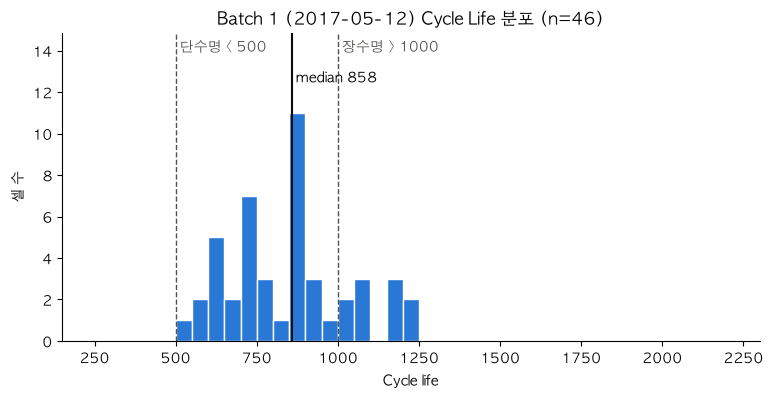

cycle_life 결측(EOL 미도달 등): 0개 셀 → 비율 계산에서 제외
count      46.0
mean      844.7
std       184.6
min       534.0
25%       703.2
50%       858.5
75%       914.2
max      1227.0 



,셀 수,비율
cycle_life,,
단수명(<500),0,0.000
중간(500~1000),36,0.783
장수명(>1000),10,0.217


IQR 이상치 기준: < 387 또는 > 1231


,policy,cycle_life,n_cycles,Q_init,Q_last
cell_id,,,,,


가장 짧은 5개 셀 + 같은 정책 셀들의 cycle_life


,policy,cycle_life,n_cycles,Q_init,Q_last,count,median,min,max
cell_id,,,,,,,,,
20,5.4C(80%)-5.4C,534.0,533.0,1.075355,0.880785,2,546.5,534.0,559.0
21,5.4C(80%)-5.4C,559.0,558.0,1.085299,0.880165,2,546.5,534.0,559.0
45,8C(35%)-3.6C,599.0,598.0,1.086933,0.881042,2,607.5,599.0,616.0
44,8C(35%)-3.6C,616.0,615.0,1.087727,0.880483,2,607.5,599.0,616.0
38,7C(40%)-3.6C,617.0,616.0,1.075375,0.881109,2,621.0,617.0,625.0


In [5]:
cells1 = eda_cycle_life(batch1, "Batch 1 (2017-05-12)")

## Batch 2 (2018-02-20)

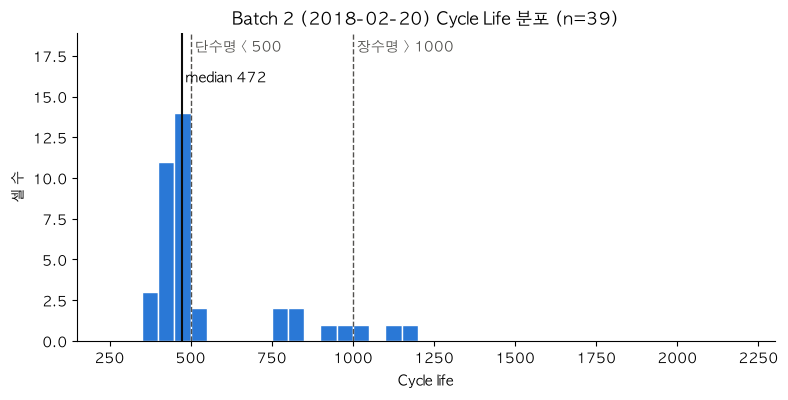

cycle_life 결측(EOL 미도달 등): 8개 셀 → 비율 계산에서 제외
count      39.0
mean      565.7
std       222.2
min       392.0
25%       439.5
50%       472.0
75%       508.5
max      1186.0 



,셀 수,비율
cycle_life,,
단수명(<500),28,0.718
중간(500~1000),8,0.205
장수명(>1000),3,0.077


IQR 이상치 기준: < 336 또는 > 612


,policy,cycle_life,n_cycles,Q_init,Q_last
cell_id,,,,,
7,4.8C(80%)-4.8C-newstructure,777.0,806.0,1.091158,0.826481
9,5.6C(26%)-4.5C-newstructure,791.0,819.0,1.098137,0.826105
32,4.8C(80%)-4.8C-newstructure,809.0,834.0,1.089830,0.827440
44,5.2C(58%)-4C-newstructure,841.0,874.0,1.098246,0.825036
8,5.2C(58%)-4C-newstructure,904.0,947.0,1.091463,0.825586
45,5.6C(26%)-4.5C-newstructure,997.0,1027.0,1.103465,0.827348
43,4.8C(80%)-4.8C-newstructure,1029.0,1061.0,1.100975,0.825324
33,5.2C(58%)-4C-newstructure,1140.0,1190.0,1.074218,0.825069
34,5.6C(26%)-4.5C-newstructure,1186.0,1252.0,1.068212,0.825624


가장 짧은 5개 셀 + 같은 정책 셀들의 cycle_life


,policy,cycle_life,n_cycles,Q_init,Q_last,count,median,min,max
cell_id,,,,,,,,,
19,6C(60%)-3C,392.0,411.0,1.092799,0.825974,2,400.0,392.0,408.0
6,3.6C(9%)-5C,393.0,409.0,1.089832,0.829404,2,394.5,393.0,396.0
15,3.6C(9%)-5C,396.0,414.0,1.070489,0.826088,2,394.5,393.0,396.0
21,6C(60%)-3C,408.0,426.0,1.100268,0.827838,2,400.0,392.0,408.0
30,5.6C(26%)-4.5C,412.0,429.0,1.096727,0.826659,6,446.0,412.0,491.0


In [6]:
cells2 = eda_cycle_life(batch2, "Batch 2 (2018-02-20)")

## Batch 3 (2018-04-12)

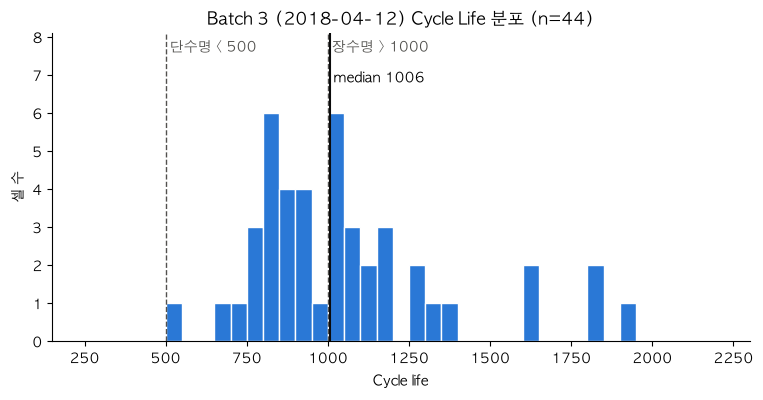

cycle_life 결측(EOL 미도달 등): 2개 셀 → 비율 계산에서 제외
count      44.0
mean     1059.7
std       313.9
min       541.0
25%       828.0
50%      1005.5
75%      1155.2
max      1935.0 



,셀 수,비율
cycle_life,,
단수명(<500),0,0.000
중간(500~1000),21,0.477
장수명(>1000),23,0.523


IQR 이상치 기준: < 337 또는 > 1646


,policy,cycle_life,n_cycles,Q_init,Q_last
cell_id,,,,,
45,4.8C(80%)-4.8C-newstructure,1801.0,1800.0,1.070962,0.880473
7,4.8C(80%)-4.8C-newstructure,1836.0,1835.0,1.069213,0.880364
38,5C(67%)-4C-newstructure,1935.0,1934.0,1.071839,0.880005


가장 짧은 5개 셀 + 같은 정책 셀들의 cycle_life


,policy,cycle_life,n_cycles,Q_init,Q_last,count,median,min,max
cell_id,,,,,,,,,
28,3.7C(31%)-5.9C-newstructure,541.0,540.0,1.052558,0.880110,3,667.0,541.0,772.0
6,3.7C(31%)-5.9C-newstructure,667.0,666.0,1.062909,0.880526,3,667.0,541.0,772.0
31,5.9C(60%)-3.1C-newstructure,731.0,730.0,1.070307,0.880314,2,866.5,731.0,1002.0
21,3.7C(31%)-5.9C-newstructure,772.0,771.0,1.068478,0.880198,3,667.0,541.0,772.0
41,5.6C(36%)-4.3C-newstructure,786.0,785.0,1.053022,0.880623,8,890.5,786.0,1155.0


In [7]:
cells3 = eda_cycle_life(batch3, "Batch 3 (2018-04-12)")

# EDA 2. 열화 곡선 - 방전 용량이 어떻게 감소하는가?

- 사이클 별 Qd 추이 시각화
- 열화 속도가 일정한가, 가속되는가?
- Knee point - 급격한 열화 시작점 탐색

배치별로 따로 봅니다. `QDischarge`는 사이클 1(0값)을 빼고, 튀는 값을 없애려고 rolling median(11)으로 다듬었습니다.

In [8]:
EOL_Q = 0.88  # 공칭 1.1Ah의 80% = 수명 종료 기준


def smooth_q(df):
    """셀별 QDischarge 정리: 사이클 1 제외, 튀는 값 제거, rolling median"""
    d = df[df["cycle"] > 1].copy()
    d.loc[~d["QDischarge"].between(0.5, 1.3), "QDischarge"] = np.nan
    d["Q_s"] = d.groupby("cell_id")["QDischarge"].transform(
        lambda s: s.rolling(11, center=True, min_periods=1).median())
    return d.dropna(subset=["Q_s"])


def find_knee(cycle, q):
    """2구간 직선 fit의 SSE가 최소가 되는 지점 = knee"""
    best, knee = np.inf, np.nan
    for i in range(20, len(cycle) - 20, 5):
        sse = 0
        for sl in (slice(None, i), slice(i, None)):
            coef = np.polyfit(cycle[sl], q[sl], 1)
            sse += ((np.polyval(coef, cycle[sl]) - q[sl]) ** 2).sum()
        if sse < best:
            best, knee = sse, cycle[i]
    return knee


def eda_degradation(df, name):
    d = smooth_q(df)
    life = d.groupby("cell_id")["cycle_life"].first()
    cmap, norm = plt.cm.Blues, plt.Normalize(life.min(), life.max())

    # 1) 사이클별 Qd 추이 (색 = cycle life, 진할수록 장수명)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for cid, g in d.groupby("cell_id"):
        color = "#b0afa8" if np.isnan(life[cid]) else cmap(0.3 + 0.7 * norm(life[cid]))
        ax.plot(g["cycle"], g["Q_s"], color=color, linewidth=1)
    ax.axhline(EOL_Q, color="#52514e", linestyle="--", linewidth=1)
    ax.text(ax.get_xlim()[1], EOL_Q, "EOL 0.88Ah ", ha="right", va="bottom", color="#52514e")
    fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label="Cycle life (회색 = 결측)")
    ax.set(xlabel="Cycle", ylabel="Qd (Ah)", title=f"{name} 사이클별 방전 용량")
    ax.spines[["top", "right"]].set_visible(False)
    plt.show()

    # 셀별 지표: 열화 속도(초반/후반), knee
    rows = []
    for cid, g in d.groupby("cell_id"):
        g = g[g["Q_s"] >= EOL_Q - 0.01]  # EOL 이후 구간 제외
        reached = g["QDischarge"].min() <= EOL_Q + 0.01  # 데이터가 EOL 직전에서 끝나는 경우 포함
        c, q = g["cycle"].to_numpy(), g["Q_s"].to_numpy()
        n = len(c)
        early = -np.polyfit(c[: n // 2], q[: n // 2], 1)[0] * 100   # 전반 50% 구간, Ah / 100cycle
        late = -np.polyfit(c[int(n * 0.8):], q[int(n * 0.8):], 1)[0] * 100  # 마지막 20% 구간
        avg = (q[0] - q[-1]) / (c[-1] - c[0]) * 100  # 전체 평균 속도
        rows.append(dict(cell_id=cid, policy=g["policy"].iat[0], cycle_life=life[cid], reached_eol=reached,
                         early_rate=early, late_rate=late, accel=late / avg,
                         knee_cycle=find_knee(c, q) if reached else np.nan))
    res = pd.DataFrame(rows).set_index("cell_id")

    # 2) 열화 속도: 수명 대비 위치(cycle / cycle_life)별 Qd 감소 속도
    r = d.copy()
    r["rate"] = -r.groupby("cell_id")["Q_s"].transform(
        lambda s: s.rolling(31, center=True, min_periods=5).mean().diff()) * 100
    r = r[r["cycle"] <= r["cycle_life"]]  # 결측(NaN) 셀도 여기서 빠짐
    r["life_frac"] = (r["cycle"] / r["cycle_life"] * 20).clip(upper=19).astype(int) / 20 + 0.025
    band = r.groupby("life_frac")["rate"].quantile([0.25, 0.5, 0.75]).unstack()

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.fill_between(band.index, band[0.25], band[0.75], color="#2a78d6", alpha=0.2, linewidth=0, label="IQR")
    ax.plot(band.index, band[0.5], color="#2a78d6", linewidth=2, marker="o", markersize=4, label="중앙값")
    ax.set(xlabel="수명 대비 위치 (cycle / cycle_life)", ylabel="Qd 감소 속도 (Ah / 100 cycle)",
           title=f"{name} 열화 속도 - 일정한가, 가속되는가?", xlim=(0, 1))
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    plt.show()

    ok = res["reached_eol"]
    print(f"EOL 도달 셀 {ok.sum()} / {len(res)}  (미도달 셀은 knee·가속비 계산 제외)")
    print("열화 속도 (Ah / 100 cycle) - early: 전반 50%, late: 마지막 20%, accel = late / 전체 평균")
    print(res.loc[ok, ["early_rate", "late_rate", "accel"]].describe().round(3).to_string(), "\n")

    # 3) Knee point: 예시 셀 4개 + knee vs cycle life
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
    ex = res[ok].sort_values("cycle_life")
    ex = ex.iloc[np.linspace(0, len(ex) - 1, 4).astype(int)]
    for cid, row in ex.iterrows():
        g = d[d["cell_id"] == cid]
        line, = ax1.plot(g["cycle"], g["Q_s"], linewidth=1.5, label=f"cell {cid} (life {row.cycle_life:.0f})")
        kq = np.interp(row.knee_cycle, g["cycle"], g["Q_s"])
        ax1.plot(row.knee_cycle, kq, "o", markersize=8, color=line.get_color(), markeredgecolor="white", markeredgewidth=2)
    ax1.axhline(EOL_Q, color="#52514e", linestyle="--", linewidth=1)
    ax1.set(xlabel="Cycle", ylabel="Qd (Ah)", title="예시 셀의 knee point (●)")
    ax1.legend(frameon=False, fontsize=9)

    ax2.scatter(res.loc[ok, "cycle_life"], res.loc[ok, "knee_cycle"], s=40, color="#2a78d6",
                edgecolor="white", linewidth=1)
    lim = [0, res.loc[ok, "cycle_life"].max() * 1.05]
    ax2.plot(lim, lim, color="#b0afa8", linewidth=1)
    ax2.text(lim[1], lim[1], "knee = EOL ", ha="right", va="bottom", color="#52514e")
    corr = res.loc[ok, ["knee_cycle", "cycle_life"]].corr().iloc[0, 1]
    ax2.set(xlabel="Cycle life", ylabel="Knee cycle", title=f"Knee vs Cycle life (r = {corr:.2f})", xlim=lim, ylim=lim)
    for a in (ax1, ax2):
        a.spines[["top", "right"]].set_visible(False)
    fig.suptitle(f"{name} Knee point", fontweight="bold")
    plt.tight_layout()
    plt.show()

    res["knee_frac"] = res["knee_cycle"] / res["cycle_life"]
    print(f"knee 위치 (knee / cycle_life) 중앙값: {res.loc[ok, 'knee_frac'].median():.2f}")
    return res

## Batch 1 (2017-05-12)

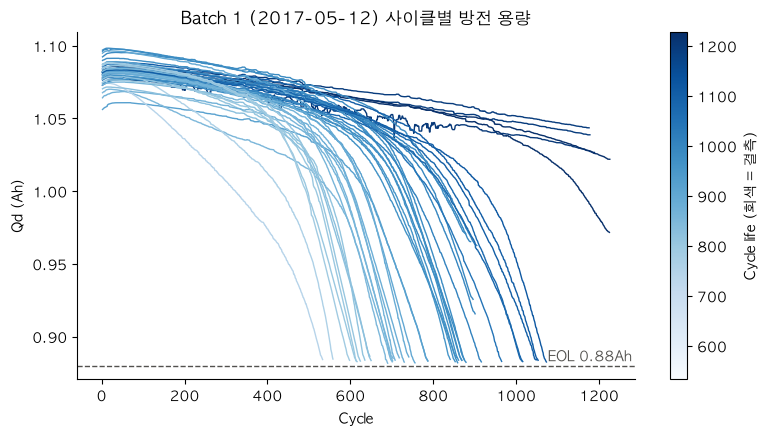

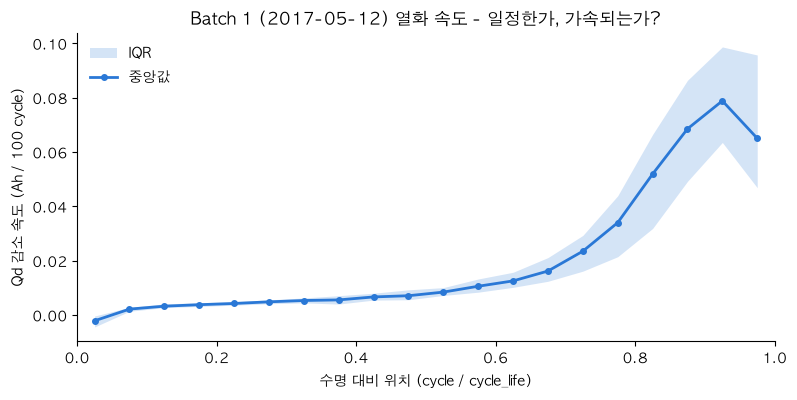

findfont: Failed to find font weight bold for AppleGothic, now using 400.


EOL 도달 셀 36 / 46  (미도달 셀은 knee·가속비 계산 제외)
열화 속도 (Ah / 100 cycle) - early: 전반 50%, late: 마지막 20%, accel = late / 전체 평균
       early_rate  late_rate   accel
count      36.000     36.000  36.000
mean        0.006      0.086   3.361
std         0.004      0.016   0.341
min         0.003      0.061   2.073
25%         0.004      0.074   3.217
50%         0.005      0.087   3.391
75%         0.005      0.098   3.553
max         0.023      0.117   3.855 



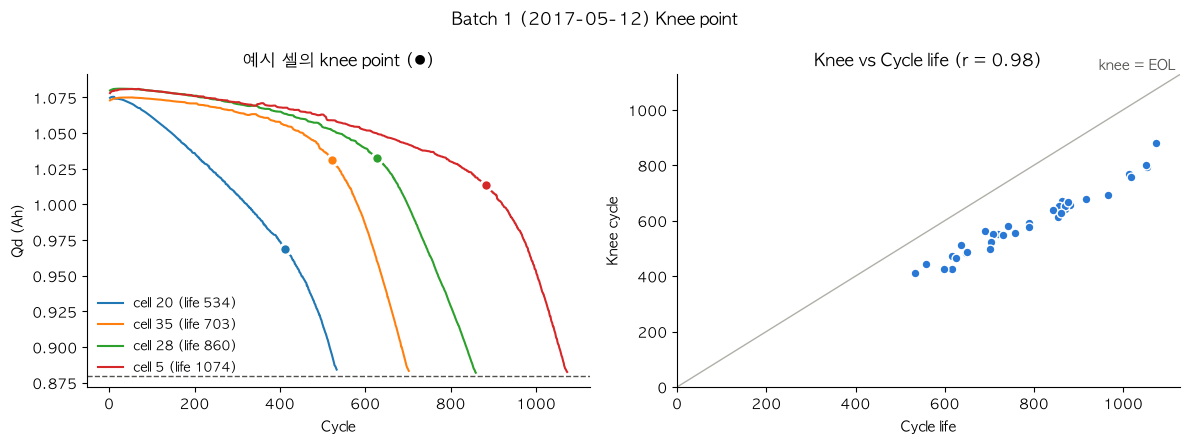

knee 위치 (knee / cycle_life) 중앙값: 0.75


In [9]:
deg1 = eda_degradation(batch1, "Batch 1 (2017-05-12)")

## Batch 2 (2018-02-20)

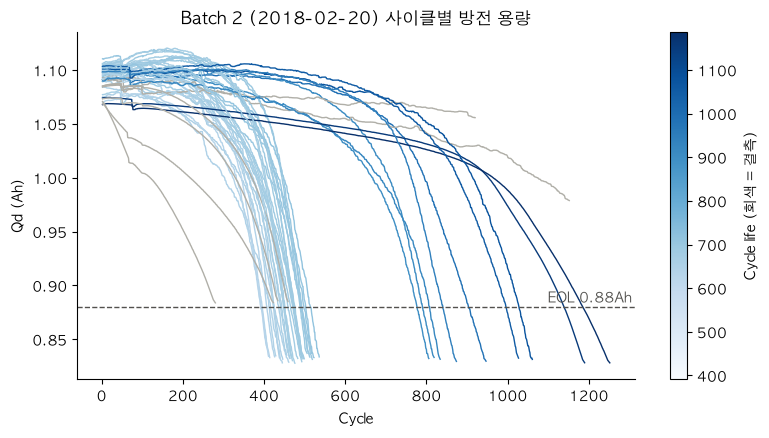

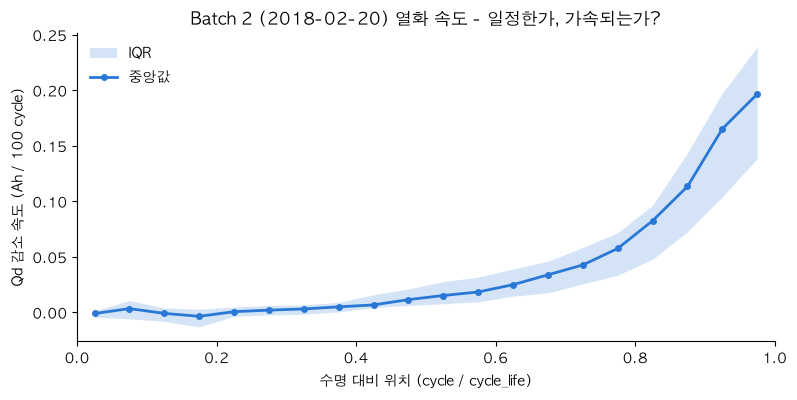

EOL 도달 셀 43 / 47  (미도달 셀은 knee·가속비 계산 제외)
열화 속도 (Ah / 100 cycle) - early: 전반 50%, late: 마지막 20%, accel = late / 전체 평균
       early_rate  late_rate   accel
count      43.000     43.000  43.000
mean        0.005      0.148   3.410
std         0.011      0.044   0.625
min        -0.007      0.056   1.371
25%        -0.000      0.118   3.107
50%         0.003      0.159   3.431
75%         0.007      0.176   3.760
max         0.059      0.214   4.477 



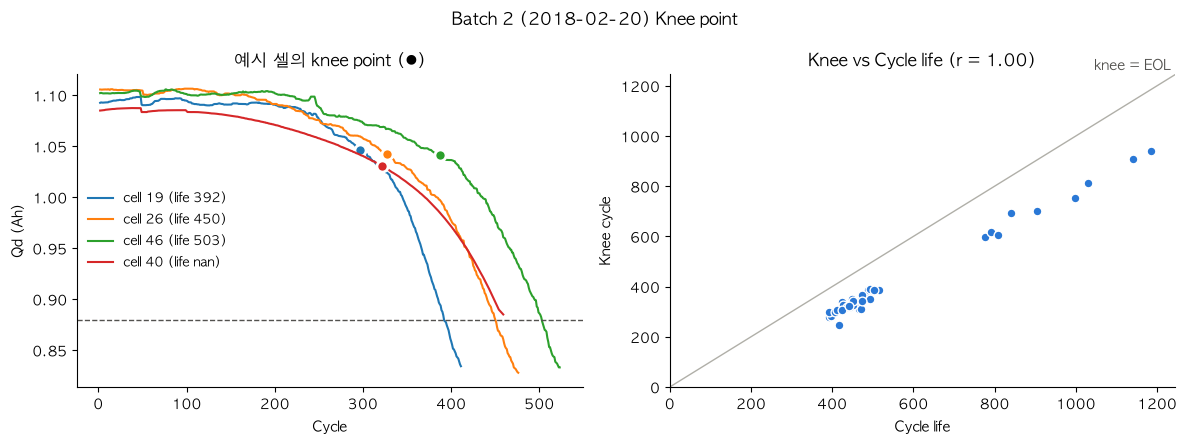

knee 위치 (knee / cycle_life) 중앙값: 0.75


In [10]:
deg2 = eda_degradation(batch2, "Batch 2 (2018-02-20)")

## Batch 3 (2018-04-12)

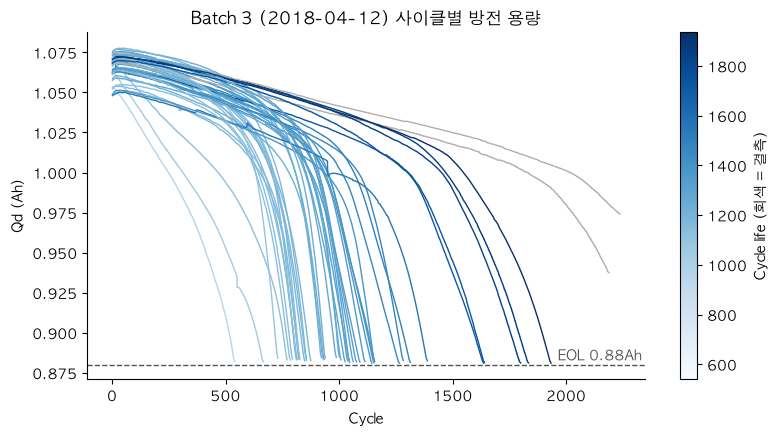

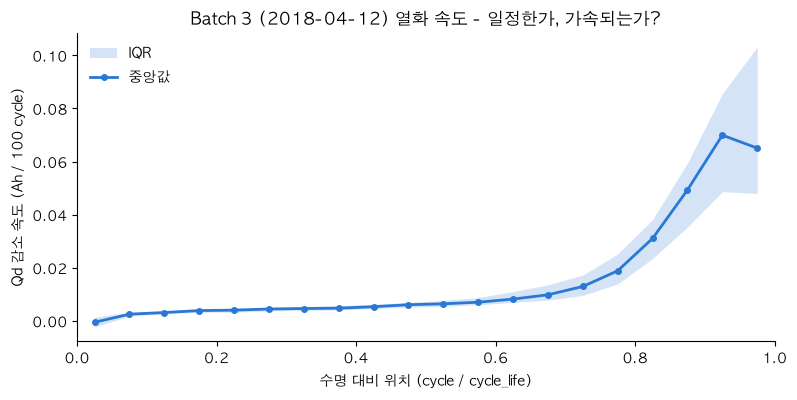

EOL 도달 셀 44 / 46  (미도달 셀은 knee·가속비 계산 제외)
열화 속도 (Ah / 100 cycle) - early: 전반 50%, late: 마지막 20%, accel = late / 전체 평균
       early_rate  late_rate   accel
count      44.000     44.000  44.000
mean        0.005      0.062   3.406
std         0.004      0.016   0.496
min         0.003      0.030   1.536
25%         0.004      0.051   3.334
50%         0.004      0.066   3.501
75%         0.005      0.073   3.676
max         0.022      0.098   3.918 



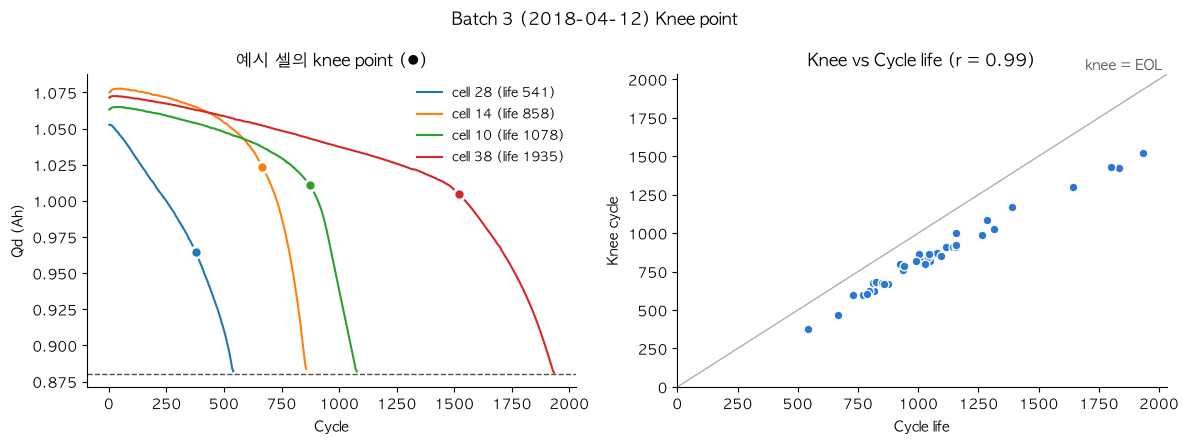

knee 위치 (knee / cycle_life) 중앙값: 0.79


In [11]:
deg3 = eda_degradation(batch3, "Batch 3 (2018-04-12)")

# EDA 3. ΔQ(V) 곡선 - 초기 사이클에서 차이가 보이는가?

- 사이클 100번 - 사이클 10번의 Q(V) 차이 계산
- 장수명 셀 vs 단수명 셀의 ΔQ 형태 비교
- 이를 구분할 수 있는 통계값으로 피처 추출

배치별로 따로 봅니다. ΔQ는 `cycles`의 `Qdlin`(2.0~3.5V를 1000점으로 보간한 방전 용량)으로 계산하고, 장수명/단수명은 배치 안에서 cycle life 상위 1/3 / 하위 1/3로 나눕니다.

In [12]:
from scipy import stats


def load_delta_q(path, cycle_a=100, cycle_b=10):
    """셀별 ΔQ(V) = Qdlin(cycle_a) - Qdlin(cycle_b).  Qdlin은 2.0~3.5V를 1000점으로 보간한 방전 용량"""
    with h5py.File(path, "r") as f:
        batch = f["batch"]
        V = f[batch["Vdlin"][0, 0]][()].ravel()
        dq = {}
        for i in range(batch["cycles"].shape[0]):
            cycles = f[batch["cycles"][i, 0]]
            q = lambda c: f[cycles["Qdlin"][c - 1, 0]][()].ravel()  # 인덱스 0 = 사이클 1
            dq[i] = q(cycle_a) - q(cycle_b)
    return V, pd.DataFrame(dq, index=V).T  # 행 = cell_id, 열 = 전압


def dq_features(dq):
    """ΔQ(V) 곡선 → 통계값 피처"""
    return pd.DataFrame({
        "log_var": np.log10(dq.var(axis=1)),
        "log_abs_min": np.log10(dq.min(axis=1).abs()),
        "log_abs_mean": np.log10(dq.mean(axis=1).abs()),
        "skew": stats.skew(dq, axis=1),
        "kurtosis": stats.kurtosis(dq, axis=1),
        "dq_at_2V": dq.iloc[:, -1],
    })


def eda_delta_q(df, path, name):
    V, dq = load_delta_q(path)
    life = df.groupby("cell_id")["cycle_life"].first()
    has_life = life.notna()

    # 1) ΔQ(V) 곡선 전체 (색 = cycle life)
    cmap, norm = plt.cm.Blues, plt.Normalize(life.min(), life.max())
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for cid, row in dq.iterrows():
        color = "#b0afa8" if np.isnan(life[cid]) else cmap(0.3 + 0.7 * norm(life[cid]))
        ax.plot(V, row, color=color, linewidth=1)
    ax.axhline(0, color="#52514e", linewidth=0.8)
    fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label="Cycle life (회색 = 결측)")
    ax.set(xlabel="Voltage (V)", ylabel="ΔQ = Q100 - Q10 (Ah)", title=f"{name} ΔQ(V) 곡선", xlim=(3.5, 2.0))
    ax.spines[["top", "right"]].set_visible(False)
    plt.show()

    # 2) 장수명 vs 단수명: 배치 안에서 cycle life 상위 1/3 vs 하위 1/3
    lo, hi = life[has_life].quantile([1 / 3, 2 / 3])
    groups = {f"단수명 (하위 1/3, < {lo:.0f})": (life < lo, "#eb6834"),
              f"장수명 (상위 1/3, > {hi:.0f})": (life > hi, "#2a78d6")}
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for label, (mask, color) in groups.items():
        g = dq[mask.reindex(dq.index, fill_value=False)]
        ax.fill_between(V, g.quantile(0.25), g.quantile(0.75), color=color, alpha=0.2, linewidth=0)
        ax.plot(V, g.median(), color=color, linewidth=2, label=f"{label}  n={len(g)}")
    ax.axhline(0, color="#52514e", linewidth=0.8)
    ax.set(xlabel="Voltage (V)", ylabel="ΔQ (Ah)", title=f"{name} 장수명 vs 단수명 ΔQ (중앙값 ± IQR)", xlim=(3.5, 2.0))
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    plt.show()

    # 3) 피처 추출 + log10(cycle life)와의 상관
    feat = dq_features(dq)
    feat["cycle_life"] = life
    f_ok = feat[has_life]
    corr = f_ok.drop(columns="cycle_life").apply(lambda s: s.corr(np.log10(f_ok["cycle_life"]))).sort_values(key=abs)
    best = corr.abs().idxmax()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
    ax1.barh(corr.index, corr.values, color=["#2a78d6" if v < 0 else "#eb6834" for v in corr.values], height=0.6)
    for y, v in enumerate(corr.values):
        ax1.text(v, y, f" {v:.2f} ", va="center", ha="left" if v >= 0 else "right", color="#0b0b0b")
    ax1.axvline(0, color="#52514e", linewidth=0.8)
    ax1.set(xlim=(-1.3, 1.3), xlabel="Pearson r  (vs log10 cycle life)", title="피처별 상관계수")

    ax2.scatter(f_ok[best], f_ok["cycle_life"], s=40, color="#2a78d6", edgecolor="white", linewidth=1)
    ax2.set_yscale("log")
    ax2.set(xlabel=best, ylabel="Cycle life (log)", title=f"가장 강한 피처: {best} (r = {corr[best]:.2f})")
    for a in (ax1, ax2):
        a.spines[["top", "right"]].set_visible(False)
    fig.suptitle(f"{name} ΔQ 피처", fontweight="bold")
    plt.tight_layout()
    plt.show()

    print("log10(cycle life)와의 상관계수:")
    print(corr.sort_values(key=abs, ascending=False).round(3).to_string())
    return feat

## Batch 1 (2017-05-12)

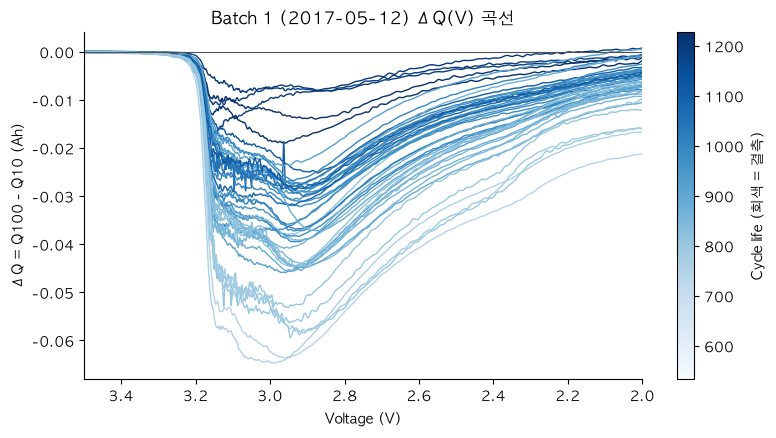

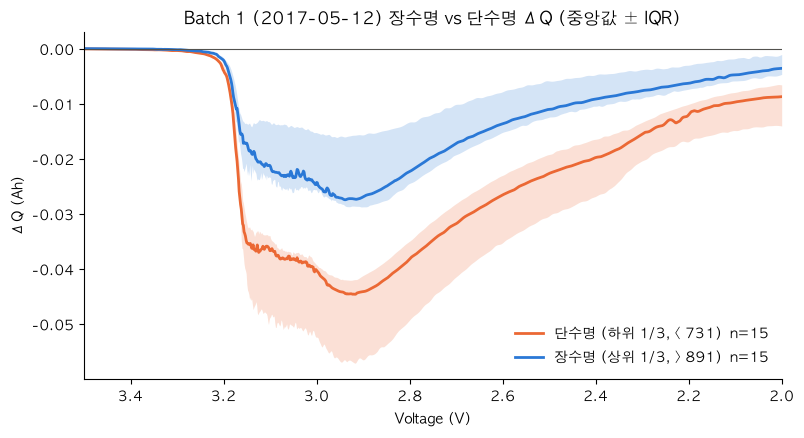

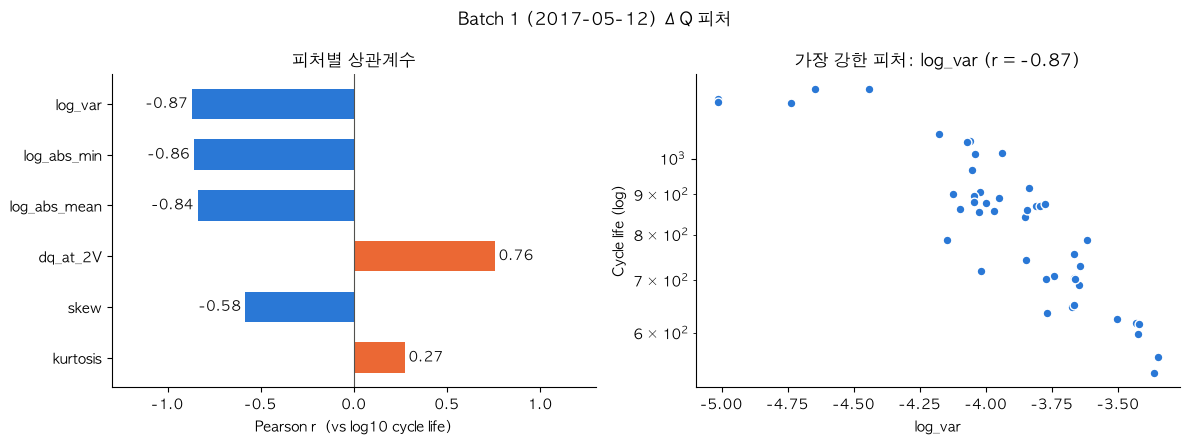

log10(cycle life)와의 상관계수:
log_var        -0.868
log_abs_min    -0.858
log_abs_mean   -0.838
dq_at_2V        0.756
skew           -0.584
kurtosis        0.272


In [13]:
dqf1 = eda_delta_q(batch1, DATA_DIR / "2017-05-12_batchdata_updated_struct_errorcorrect.mat", "Batch 1 (2017-05-12)")

## Batch 2 (2018-02-20)

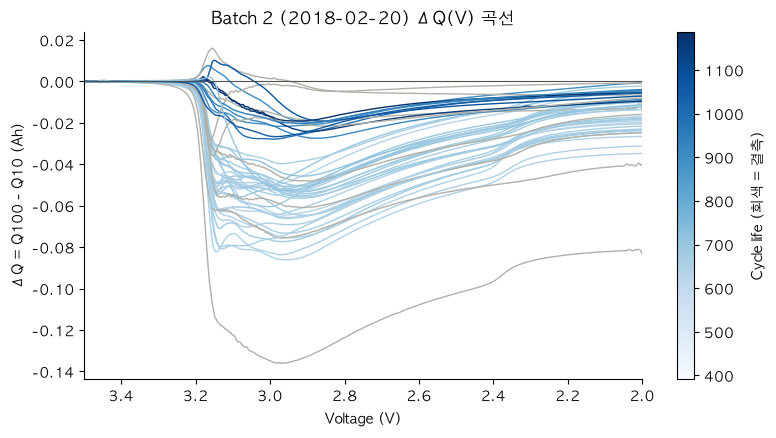

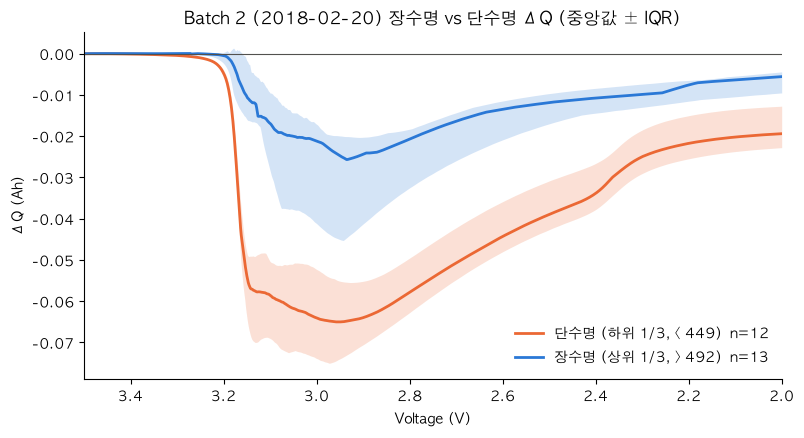

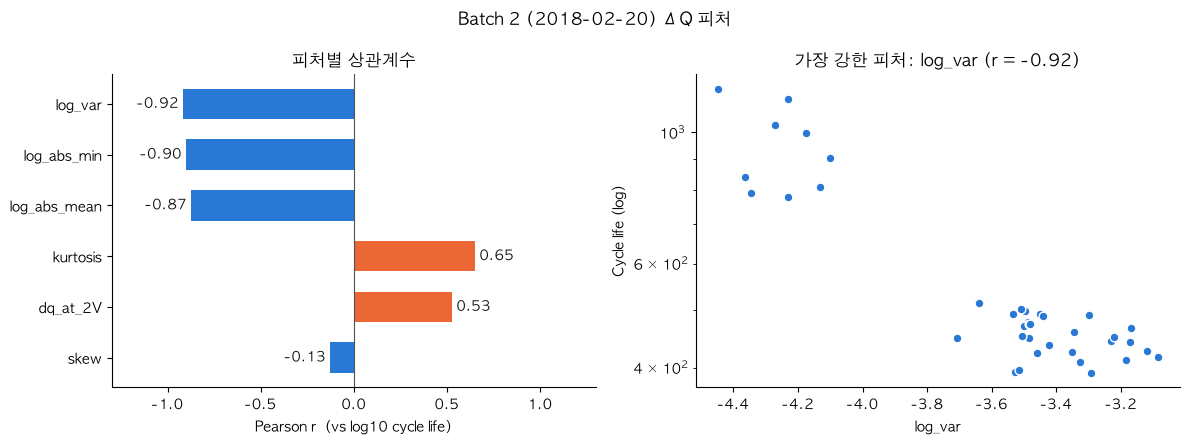

log10(cycle life)와의 상관계수:
log_var        -0.918
log_abs_min    -0.901
log_abs_mean   -0.874
kurtosis        0.653
dq_at_2V        0.529
skew           -0.126


In [14]:
dqf2 = eda_delta_q(batch2, DATA_DIR / "2018-02-20_batchdata_updated_struct_errorcorrect.mat", "Batch 2 (2018-02-20)")

## Batch 3 (2018-04-12)

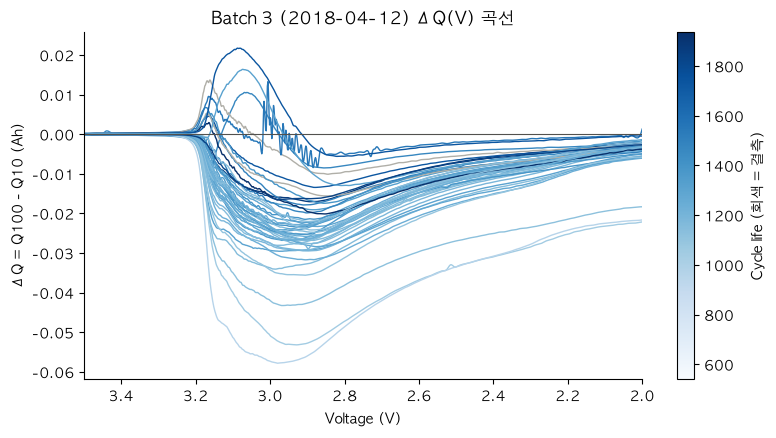

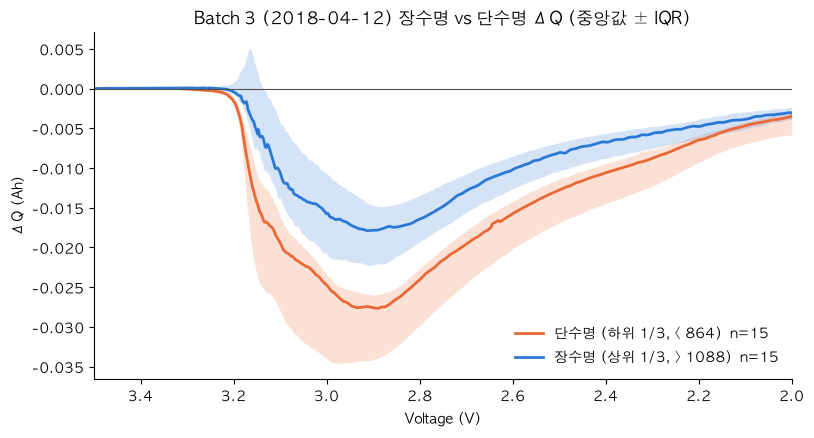

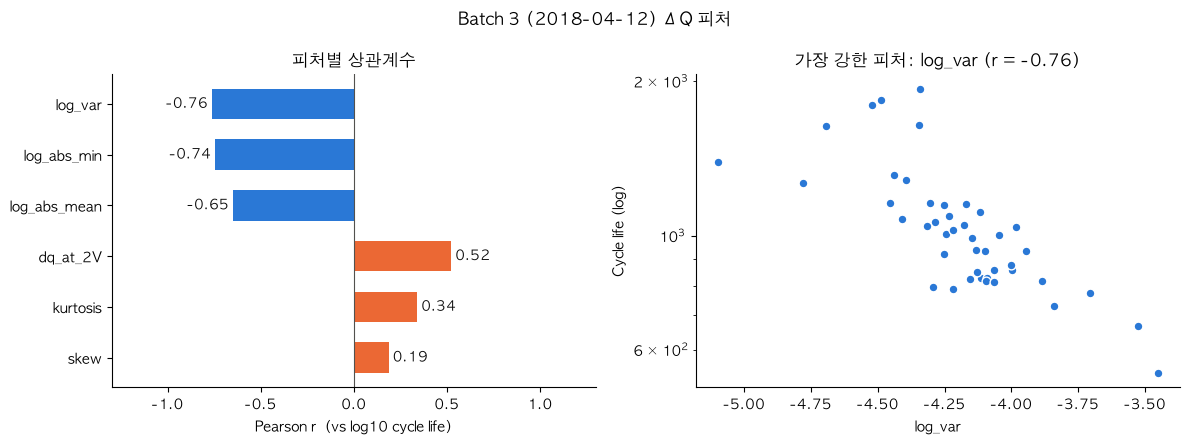

log10(cycle life)와의 상관계수:
log_var        -0.762
log_abs_min    -0.744
log_abs_mean   -0.648
dq_at_2V        0.523
kurtosis        0.341
skew            0.188


In [15]:
dqf3 = eda_delta_q(batch3, DATA_DIR / "2018-04-12_batchdata_updated_struct_errorcorrect.mat", "Batch 3 (2018-04-12)")

# EDA 4. 충전 조건 (C-rate)과 수명의 관계는?

- 충전 프로토콜별 평균 수명 비교
- 고속 충전 셀이 정말 수명이 짧은가?
- 충전 전류 패턴과 열화 속도 상관 분석

배치별로 따로 봅니다. 정책 문자열 `C1(Q1%)-C2`를 파싱해 0→80% SOC 충전 시간과 평균 C-rate를 계산하고 (`VarCharge` 정책은 형식이 달라 제외), 열화 지표는 EDA 2 결과(`deg1~3`)를 씁니다.

⚠️ Batch 2·3는 모든 정책의 0→80% 충전 시간이 약 10분(평균 ≈ 4.8C)으로 같도록 설계돼 있습니다. 그래서 이 두 배치는 평균 C-rate로 비교할 수 없고, 같은 충전 시간 안에서 **전류를 어떻게 배분했는지**(C1, Q1, C2)를 비교합니다.

In [16]:
import re


def parse_policy(policy):
    """'5.6C(26%)-4.5C-newstructure' → C1, Q1(전환 SOC %), C2.  VarCharge 등 형식이 다르면 NaN"""
    m = re.match(r"([\d.]+)C\((\d+)%\)-([\d.]+)C", policy)
    if m is None:
        return pd.Series({"C1": np.nan, "Q1": np.nan, "C2": np.nan})
    return pd.Series({"C1": float(m[1]), "Q1": float(m[2]), "C2": float(m[3])})


def charge_table(df, deg):
    """셀 단위 충전 조건 + 열화 지표(EDA 2 결과) 테이블"""
    early = df[df["cycle"].between(2, 101)]
    cells = df.groupby("cell_id").agg(policy=("policy", "first"), cycle_life=("cycle_life", "first"))
    cells = cells.join(cells["policy"].apply(parse_policy))
    # 0→80% SOC 충전 시간(분)과 평균 C-rate: 1단계 C1으로 Q1%까지, 2단계 C2로 80%까지
    cells["t80_min"] = 60 * (cells["Q1"] / 100 / cells["C1"] + (80 - cells["Q1"]) / 100 / cells["C2"])
    cells["avg_C"] = 0.8 * 60 / cells["t80_min"]
    cells["newstructure"] = cells["policy"].str.contains("newstructure")
    cells["Tmax"] = early[early["Tmax"] > 0].groupby("cell_id")["Tmax"].median()  # 초기 100사이클 최고 온도
    return cells.join(deg[["early_rate", "late_rate", "accel", "knee_frac"]])


def eda_charging(df, deg, name):
    cells = charge_table(df, deg)
    ok = cells["cycle_life"].notna() & cells["avg_C"].notna()
    c = cells[ok]
    print(f"분석 대상 {ok.sum()} / {len(cells)}셀  (cycle_life 결측 또는 VarCharge 등 정책 파싱 불가 셀 제외)")
    cmap, norm = plt.cm.Blues, plt.Normalize(c["avg_C"].min(), c["avg_C"].max())

    # 1) 충전 프로토콜별 평균 수명 (평균 C-rate 순 정렬, 막대 색 = 평균 C-rate)
    pol = c.groupby("policy").agg(avg_C=("avg_C", "first"), n=("cycle_life", "size"),
                                  mean_life=("cycle_life", "mean")).sort_values("avg_C")
    fig, ax = plt.subplots(figsize=(9, 0.32 * len(pol) + 1.5))
    y = np.arange(len(pol))
    ax.barh(y, pol["mean_life"], color=cmap(0.3 + 0.7 * norm(pol["avg_C"])), height=0.7)
    for i, p in enumerate(pol.index):
        ax.scatter(c.loc[c["policy"] == p, "cycle_life"], [i] * (c["policy"] == p).sum(),
                   s=14, color="#0b0b0b", zorder=3)
    ax.set_yticks(y, [f"{p}  (n={n})" for p, n in zip(pol.index, pol["n"])], fontsize=8)
    fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label="평균 C-rate (0→80%)")
    ax.set(xlabel="Cycle life (막대 = 평균, ● = 개별 셀)", title=f"{name} 충전 프로토콜별 평균 수명")
    ax.spines[["top", "right"]].set_visible(False)
    plt.show()
    display(pol.sort_values("mean_life").round(2))

    # 2) 고속 충전 셀이 정말 수명이 짧은가?
    #    평균 C-rate(= 0→80% 충전 시간)와 최대 전류 C1 각각 vs 수명.
    #    평균 C-rate가 모두 같은 배치(≈4.8C, 10분 충전)는 C1 기준으로 고속/저속을 나눔
    split = "avg_C" if c["avg_C"].round(1).nunique() > 1 else "C1"
    fast = c[split] > c[split].median()
    _, p_mw = stats.mannwhitneyu(c.loc[fast, "cycle_life"], c.loc[~fast, "cycle_life"])

    mixed = c["newstructure"].nunique() > 1
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), gridspec_kw={"width_ratios": [2, 2, 1.3]})
    for ax, col, label in [(axes[0], "avg_C", "평균 C-rate (0→80% SOC)"), (axes[1], "C1", "C1 = 1단계(최대) 전류 C-rate")]:
        rho, p = stats.spearmanr(c[col], c["cycle_life"])
        if mixed:  # 셀 구조가 섞인 배치(Batch 2)는 구조별로 색 구분
            for is_new, color, lab in [(False, "#2a78d6", "기존 셀"), (True, "#eb6834", "newstructure 셀")]:
                m = c["newstructure"] == is_new
                ax.scatter(c.loc[m, col], c.loc[m, "cycle_life"], s=40, color=color, edgecolor="white", linewidth=1, label=lab)
            ax.legend(frameon=False, fontsize=9)
        else:
            ax.scatter(c[col], c["cycle_life"], s=40, color="#2a78d6", edgecolor="white", linewidth=1)
        if c[col].round(1).nunique() > 1:
            coef = np.polyfit(c[col], c["cycle_life"], 1)
            xs = np.linspace(c[col].min(), c[col].max(), 50)
            ax.plot(xs, np.polyval(coef, xs), color="#52514e", linestyle="--", linewidth=1)
            ax.set_title(f"{col} vs 수명 (Spearman ρ = {rho:.2f}, p = {p:.3f})")
        else:
            ax.set_title(f"{col} vs 수명 (모든 셀 ≈ {c[col].median():.1f}C → 비교 불가)")
            ax.set_xlim(c[col].median() - 0.5, c[col].median() + 0.5)
        ax.set(xlabel=label, ylabel="Cycle life")

    groups = [("저속", ~fast, "#2a78d6"), ("고속", fast, "#eb6834")]
    bp = axes[2].boxplot([c.loc[m, "cycle_life"] for _, m, _ in groups], widths=0.5, patch_artist=True,
                         medianprops=dict(color="#0b0b0b"))
    for patch, (_, _, color) in zip(bp["boxes"], groups):
        patch.set(facecolor=color, alpha=0.4, edgecolor=color)
    axes[2].set_xticks([1, 2], [f"{g} (n={m.sum()})" for g, m, _ in groups])
    axes[2].set(ylabel="Cycle life",
                title=f"{split} 중앙값({c[split].median():.2f}C) 기준\nMann-Whitney p = {p_mw:.3f}")
    for a in axes:
        a.spines[["top", "right"]].set_visible(False)
    fig.suptitle(f"{name} 고속 충전 셀이 정말 수명이 짧은가?", fontweight="bold")
    plt.tight_layout()
    plt.show()

    # 3) 충전 전류 패턴 ↔ 열화 속도 상관 (Spearman, EOL 미도달 셀은 knee/accel이 NaN → 쌍별 제외)
    x_cols = ["C1", "Q1", "C2", "avg_C", "Tmax"]
    y_cols = ["early_rate", "late_rate", "accel", "knee_frac", "cycle_life"]
    corr = c[x_cols + y_cols].corr(method="spearman").loc[x_cols, y_cols]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    for i in range(len(x_cols)):
        for j in range(len(y_cols)):
            v = corr.iat[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", color="white" if abs(v) > 0.6 else "#0b0b0b")
    ax.set_xticks(range(len(y_cols)), y_cols)
    ax.set_yticks(range(len(x_cols)), ["C1 (1단계 전류)", "Q1 (전환 SOC %)", "C2 (2단계 전류)", "avg_C", "Tmax (초기 최고온도)"])
    fig.colorbar(im, ax=ax, label="Spearman ρ")
    ax.set_title(f"{name} 충전 조건 ↔ 열화 지표 상관")
    plt.show()

    print("Spearman ρ (충전 조건 × 열화 지표)  - early_rate/late_rate 단위: Ah / 100 cycle")
    print(corr.round(2).to_string())
    return cells


## Batch 1 (2017-05-12)

분석 대상 46 / 46셀  (cycle_life 결측 또는 VarCharge 등 정책 파싱 불가 셀 제외)


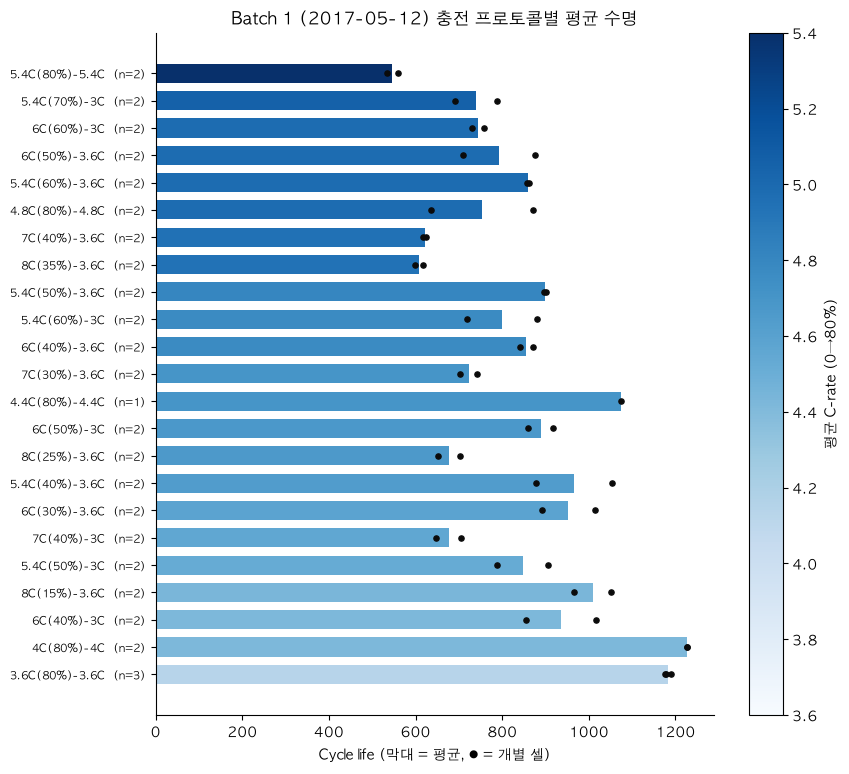

,avg_C,n,mean_life
policy,,,
5.4C(80%)-5.4C,5.40,2,546.5
8C(35%)-3.6C,4.74,2,607.5
7C(40%)-3.6C,4.75,2,621.0
7C(40%)-3C,4.20,2,676.0
8C(25%)-3.6C,4.35,2,676.5
7C(30%)-3.6C,4.40,2,722.5
5.4C(70%)-3C,4.91,2,739.5
6C(60%)-3C,4.80,2,744.0
4.8C(80%)-4.8C,4.80,2,753.0


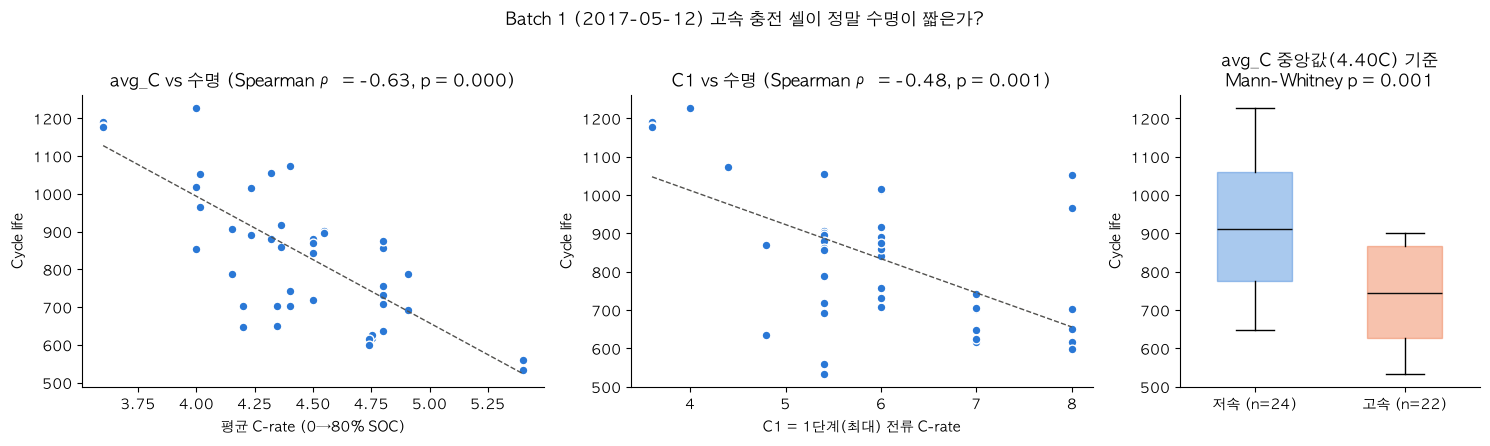

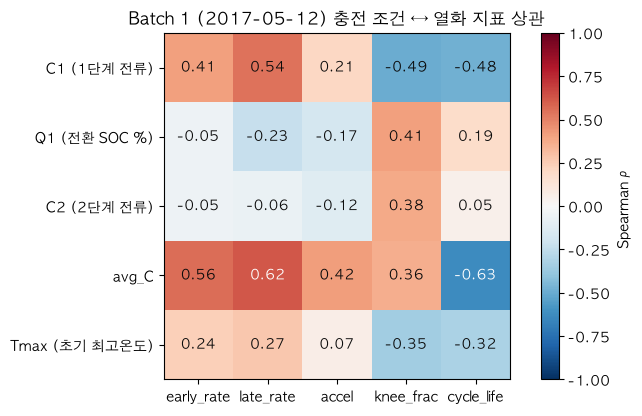

Spearman ρ (충전 조건 × 열화 지표)  - early_rate/late_rate 단위: Ah / 100 cycle
       early_rate  late_rate  accel  knee_frac  cycle_life
C1           0.41       0.54   0.21      -0.49       -0.48
Q1          -0.05      -0.23  -0.17       0.41        0.19
C2          -0.05      -0.06  -0.12       0.38        0.05
avg_C        0.56       0.62   0.42       0.36       -0.63
Tmax         0.24       0.27   0.07      -0.35       -0.32


In [17]:
chg1 = eda_charging(batch1, deg1, "Batch 1 (2017-05-12)")

## Batch 2 (2018-02-20)

분석 대상 39 / 47셀  (cycle_life 결측 또는 VarCharge 등 정책 파싱 불가 셀 제외)


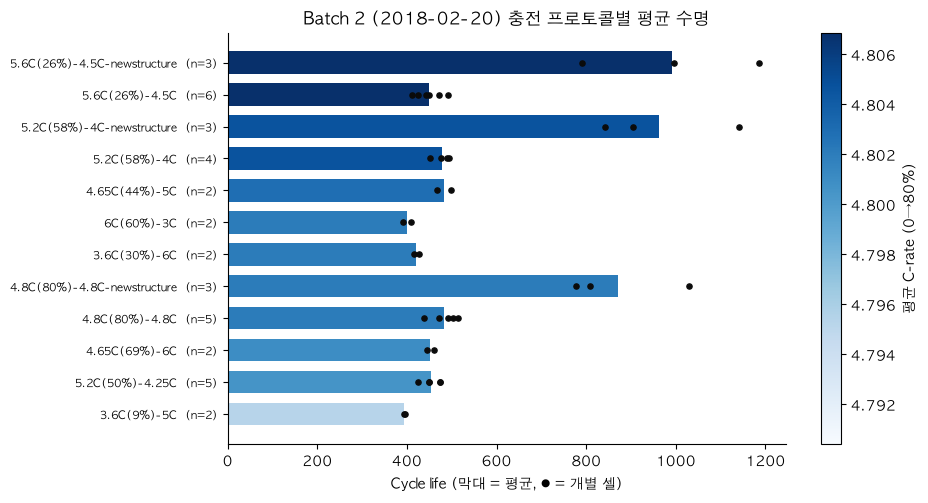

,avg_C,n,mean_life
policy,,,
3.6C(9%)-5C,4.79,2,394.50
6C(60%)-3C,4.80,2,400.00
3.6C(30%)-6C,4.80,2,421.00
5.6C(26%)-4.5C,4.81,6,448.50
4.65C(69%)-6C,4.80,2,452.00
5.2C(50%)-4.25C,4.80,5,454.00
5.2C(58%)-4C,4.80,4,477.75
4.65C(44%)-5C,4.80,2,482.50
4.8C(80%)-4.8C,4.80,5,483.60


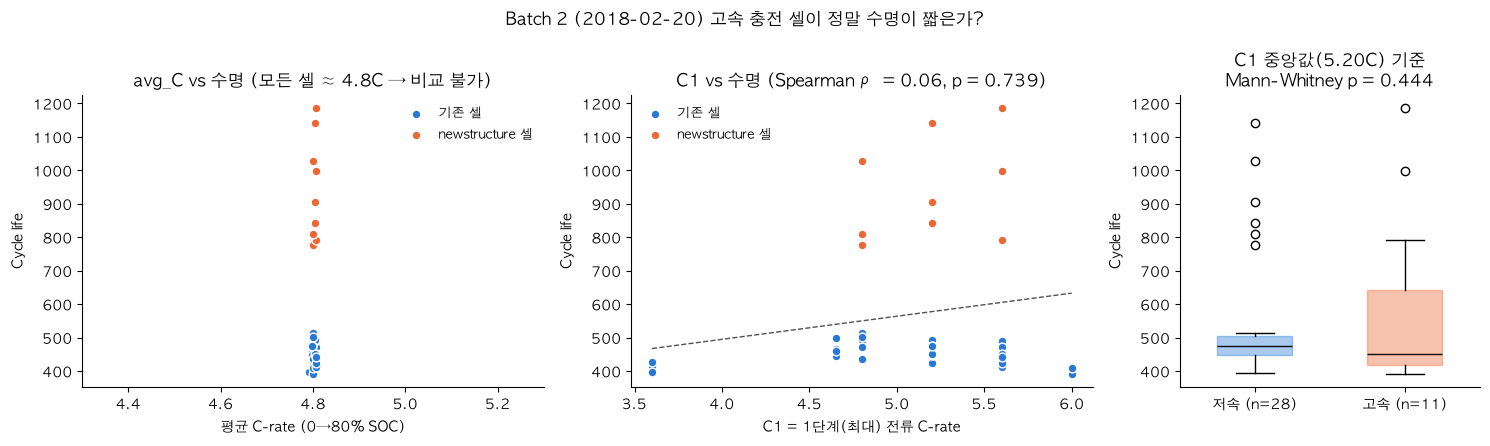

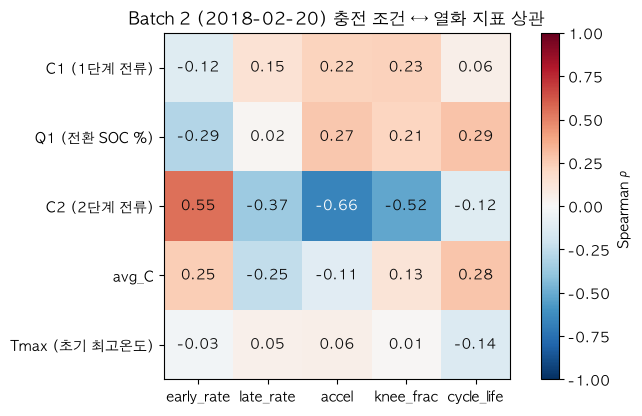

Spearman ρ (충전 조건 × 열화 지표)  - early_rate/late_rate 단위: Ah / 100 cycle
       early_rate  late_rate  accel  knee_frac  cycle_life
C1          -0.12       0.15   0.22       0.23        0.06
Q1          -0.29       0.02   0.27       0.21        0.29
C2           0.55      -0.37  -0.66      -0.52       -0.12
avg_C        0.25      -0.25  -0.11       0.13        0.28
Tmax        -0.03       0.05   0.06       0.01       -0.14


In [18]:
chg2 = eda_charging(batch2, deg2, "Batch 2 (2018-02-20)")

## Batch 3 (2018-04-12)

분석 대상 44 / 46셀  (cycle_life 결측 또는 VarCharge 등 정책 파싱 불가 셀 제외)


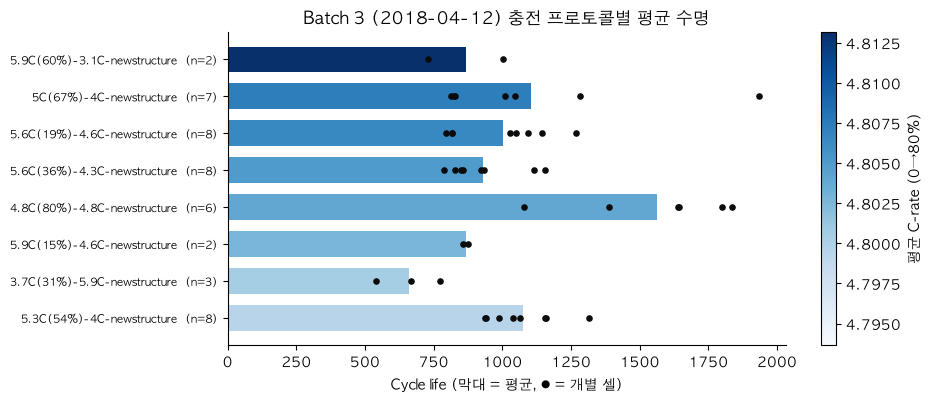

,avg_C,n,mean_life
policy,,,
3.7C(31%)-5.9C-newstructure,4.80,3,660.00
5.9C(60%)-3.1C-newstructure,4.81,2,866.50
5.9C(15%)-4.6C-newstructure,4.80,2,867.00
5.6C(36%)-4.3C-newstructure,4.80,8,930.88
5.6C(19%)-4.6C-newstructure,4.80,8,1001.38
5.3C(54%)-4C-newstructure,4.79,8,1074.38
5C(67%)-4C-newstructure,4.80,7,1105.71
4.8C(80%)-4.8C-newstructure,4.80,6,1564.17


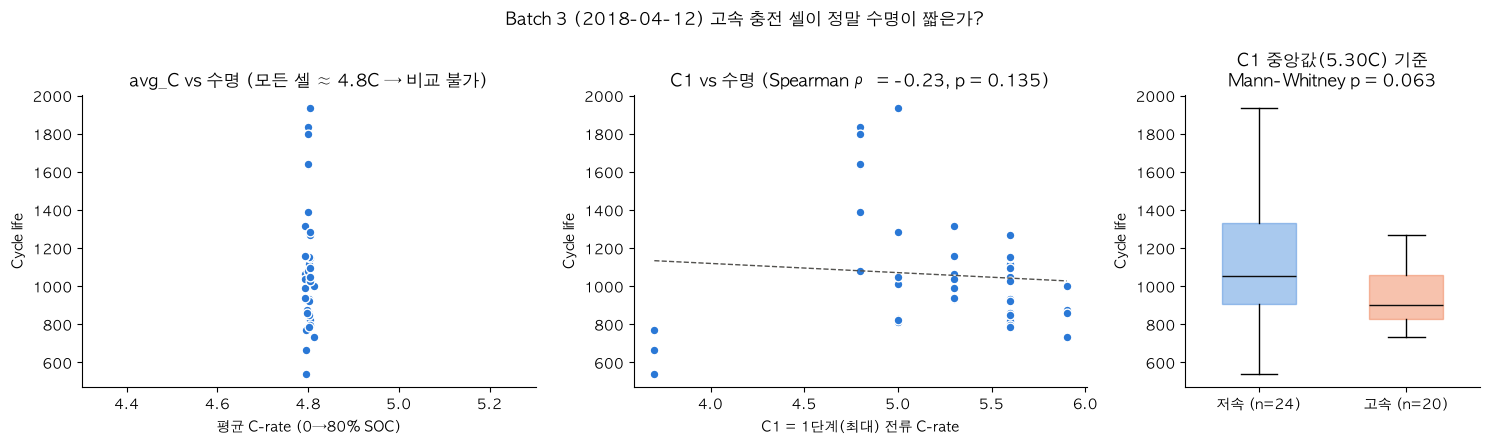

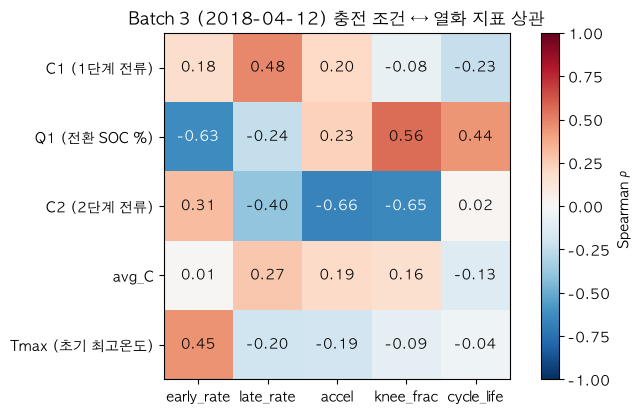

Spearman ρ (충전 조건 × 열화 지표)  - early_rate/late_rate 단위: Ah / 100 cycle
       early_rate  late_rate  accel  knee_frac  cycle_life
C1           0.18       0.48   0.20      -0.08       -0.23
Q1          -0.63      -0.24   0.23       0.56        0.44
C2           0.31      -0.40  -0.66      -0.65        0.02
avg_C        0.01       0.27   0.19       0.16       -0.13
Tmax         0.45      -0.20  -0.19      -0.09       -0.04


In [19]:
chg3 = eda_charging(batch3, deg3, "Batch 3 (2018-04-12)")

# EDA 5. 상관관계 - 어떤 신호가 수명과 연관되어 있는가?

- 초기 사이클 피처들과 Cycle Life 상관 계수 확인
- 가장 강한 관계 식별
- 멀티콜리니어리티 문제 확인

배치별로 따로 봅니다. 피처는 두 종류이고, 모두 **초기 100사이클 안에서** 계산합니다.
- `summary` 기반 12개: 방전 용량(Q2, Q100, Qmax−Q2, 2~100 / 91~100 기울기), 내부저항(IR2, IR_min, IR_diff), 온도(Tavg 평균, Tmax 최대, Tmin 최소), 충전 시간(사이클 2~6 평균)
- EDA 3의 ΔQ(V) 피처 6개 (`dqf1~3`)

상관은 EDA 3과 같이 log10(cycle life) 기준이고 Pearson과 Spearman을 함께 봅니다. 멀티콜리니어리티는 피처 간 |r| 히트맵과 VIF(≥ 10이면 문제)로 확인합니다. 또 VIF가 가장 큰 피처를 하나씩 빼서 모든 VIF가 10 미만이 되는 피처 조합을 구합니다.

⚠️ Batch 2는 `newstructure` 셀(충전 시간 ≈10.04분, 수명 약 2배)과 기존 셀(≈10.17분)이 섞여 있습니다. 그래서 일부 피처의 높은 상관은 연속적인 관계가 아니라 두 그룹 간 차이일 수 있습니다. Top 3 산점도에서 구조별로 색을 나눠 확인합니다.

In [20]:
from scipy.cluster import hierarchy

EARLY = 100  # 초기 사이클 범위: 2 ~ 100


def early_features(df):
    """summary의 초기 100사이클 → 셀 단위 피처 (사이클 1과 0/튀는 값은 제외)"""
    d = smooth_q(df)
    d = d[d["cycle"] <= EARLY]
    rows = []
    for cid, g in d.groupby("cell_id"):
        c, q = g["cycle"].to_numpy(), g["Q_s"].to_numpy()
        last = g["cycle"] > EARLY - 10
        ir = g.loc[g["IR"] > 0, "IR"]
        t = g[["Tavg", "Tmax", "Tmin"]]
        t = t.where(t.ge(20) & t.le(50))  # 0·음수·센서 이상(400°C) 값 제외 → NaN
        ir = ir if len(ir) else pd.Series([np.nan])  # IR이 전부 0으로 기록된 셀 → NaN (분석에서 제외)
        rows.append(dict(
            cell_id=cid,
            Q2=q[0], Q100=q[-1],
            Qmax_minus_Q2=q.max() - q[0],
            slope_2_100=np.polyfit(c, q, 1)[0] * 100,                 # Ah / 100 cycle
            slope_91_100=np.polyfit(c[last], q[last], 1)[0] * 100,
            IR2=ir.iat[0], IR_min=ir.min(),
            IR_diff=ir.iat[-1] - ir.iat[0],                           # IR(100) - IR(2)
            Tavg_mean=t["Tavg"].mean(), Tmax_max=t["Tmax"].max(), Tmin_min=t["Tmin"].min(),
            chargetime_2_6=g.loc[g["cycle"] <= 6, "chargetime"].mean(),  # 분
        ))
    return pd.DataFrame(rows).set_index("cell_id")


def vif(X):
    """VIF_i = 1 / (1 - R²_i),  R²_i = 피처 i를 나머지 피처로 회귀했을 때의 설명력"""
    Z = ((X - X.mean()) / X.std()).to_numpy()
    out = {}
    for i, col in enumerate(X.columns):
        others = np.delete(Z, i, axis=1)
        beta, *_ = np.linalg.lstsq(others, Z[:, i], rcond=None)
        r2 = 1 - ((Z[:, i] - others @ beta) ** 2).sum() / (Z[:, i] ** 2).sum()
        out[col] = np.inf if r2 >= 1 - 1e-10 else 1 / (1 - r2)
    return pd.Series(out)


def prune_vif(X, limit=10):
    """VIF가 가장 큰 피처를 하나씩 빼면서 모두 limit 미만이 될 때까지 반복"""
    X, dropped = X.copy(), []
    while True:
        v = vif(X)
        if v.max() < limit:
            return v.sort_values(ascending=False), dropped
        dropped.append(v.idxmax())
        X = X.drop(columns=v.idxmax())


def eda_correlation(df, dqf, name):
    feat = early_features(df).join(dqf.drop(columns="cycle_life"))
    life = df.groupby("cell_id")["cycle_life"].first()
    ok = life.notna()
    X, y = feat[ok], np.log10(life[ok])
    full = X.notna().all(axis=1)  # VIF·피처 간 상관은 결측 없는 셀만 사용
    print(f"분석 대상 {ok.sum()} / {len(feat)}셀 (cycle_life 결측 제외), 피처 {X.shape[1]}개")
    if not full.all():
        print(f"  피처 결측 셀 {(~full).sum()}개 (예: IR이 전부 0으로 기록) → life 상관은 피처별로 가능한 셀만, VIF는 {full.sum()}셀로 계산")

    # 1) 피처별 log10(cycle life)와의 상관: Pearson(막대) + Spearman(●)
    pear = X.apply(lambda s: s.corr(y)).sort_values(key=abs)
    spear = X.apply(lambda s: s.corr(y, method="spearman"))[pear.index]
    fig, ax = plt.subplots(figsize=(9, 0.32 * len(pear) + 1.5))
    yy = np.arange(len(pear))
    ax.barh(yy, pear, color=["#2a78d6" if v < 0 else "#eb6834" for v in pear], height=0.6, label="Pearson r")
    ax.scatter(spear, yy, s=22, color="#0b0b0b", zorder=3, label="Spearman ρ")
    for i, v in enumerate(pear):
        ax.text(v, i, f" {v:.2f} ", va="center", ha="left" if v >= 0 else "right", fontsize=8)
    ax.set_yticks(yy, pear.index, fontsize=9)
    ax.axvline(0, color="#52514e", linewidth=0.8)
    ax.set(xlim=(-1.2, 1.2), xlabel="상관계수 (vs log10 cycle life)", title=f"{name} 초기 사이클 피처 ↔ Cycle life 상관")
    ax.legend(frameon=False, loc="lower right")
    ax.spines[["top", "right"]].set_visible(False)
    plt.show()

    # 2) 가장 강한 관계: |r| 상위 3개 피처 산점도
    #    셀 구조가 섞인 배치(Batch 2)는 newstructure 셀을 주황으로 → 구조 차이가 상관을 만드는지 확인
    top = pear.abs().sort_values(ascending=False).index[:3]
    is_new = df.groupby("cell_id")["policy"].first().str.contains("newstructure")[ok]
    colors = np.where(is_new, "#eb6834", "#2a78d6") if is_new.nunique() > 1 else "#2a78d6"
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    for ax, col in zip(axes, top):
        m = X[col].notna()
        ax.scatter(X.loc[m, col], life[ok][m], s=40, color=colors if isinstance(colors, str) else colors[m],
                   edgecolor="white", linewidth=1)
        ax.ticklabel_format(axis="x", useOffset=False)
        ax.xaxis.set_major_locator(plt.MaxNLocator(5))
        coef = np.polyfit(X.loc[m, col], y[m], 1)
        xs = np.linspace(X[col].min(), X[col].max(), 50)
        ax.plot(xs, 10 ** np.polyval(coef, xs), color="#52514e", linestyle="--", linewidth=1)
        ax.set_yscale("log")
        ax.set(xlabel=col, ylabel="Cycle life (log)", title=f"{col}  (r = {pear[col]:.2f})")
        ax.spines[["top", "right"]].set_visible(False)
    if is_new.nunique() > 1:
        axes[0].scatter([], [], color="#eb6834", label="newstructure 셀")
        axes[0].scatter([], [], color="#2a78d6", label="기존 셀")
        axes[0].legend(frameon=False, fontsize=9)
    fig.suptitle(f"{name} 가장 강한 관계 Top 3", fontweight="bold")
    plt.tight_layout()
    plt.show()

    # 3) 멀티콜리니어리티: 피처 간 |r| (계층 군집 순서로 정렬 → 비슷한 피처끼리 블록) + VIF
    Xf = X[full]
    corr = Xf.corr()
    order = hierarchy.leaves_list(hierarchy.linkage(Xf.T.to_numpy(), "average", metric="correlation"))
    corr = corr.iloc[order, order]
    v = vif(Xf)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5), gridspec_kw={"width_ratios": [1.6, 1]})
    im = ax1.imshow(corr.abs(), cmap="Blues", vmin=0, vmax=1)
    ax1.set_xticks(range(len(corr)), corr.index, rotation=90, fontsize=8)
    ax1.set_yticks(range(len(corr)), corr.index, fontsize=8)
    fig.colorbar(im, ax=ax1, label="|Pearson r|", shrink=0.8)
    ax1.set_title("피처 간 |상관| (군집 순서)")

    v_plot = v.replace(np.inf, 1e6).loc[corr.index[::-1]]
    ax2.barh(v_plot.index, v_plot, color=["#eb6834" if x >= 10 else "#2a78d6" for x in v_plot], height=0.6)
    ax2.axvline(10, color="#52514e", linestyle="--", linewidth=1)
    ax2.text(10, len(v_plot) - 0.5, " VIF = 10", color="#52514e", va="bottom")
    ax2.set_xscale("log")
    ax2.tick_params(axis="y", labelsize=8)
    ax2.set(xlabel="VIF (log, 1e6 = 완전 공선)", title="VIF  (≥ 10 → 다중공선성)")
    ax2.spines[["top", "right"]].set_visible(False)
    fig.suptitle(f"{name} 멀티콜리니어리티", fontweight="bold")
    plt.tight_layout()
    plt.show()

    pairs = corr.where(np.triu(np.ones(corr.shape, bool), 1)).stack()
    print("|r| ≥ 0.9 인 피처 쌍:")
    print(pairs[pairs.abs() >= 0.9].sort_values(key=abs, ascending=False).round(3).to_string(), "\n")
    kept, dropped = prune_vif(Xf)
    print(f"VIF ≥ 10 피처: {(v >= 10).sum()} / {len(v)}개")
    print(f"VIF 큰 순서로 제거 → 남은 {len(kept)}개 (모두 VIF < 10), 제거 순서: {dropped}")
    display(pd.DataFrame({"VIF": kept.round(2), "r (log life)": pear[kept.index].round(3)}))

    res = pd.DataFrame({"pearson": pear, "spearman": spear, "VIF": v}).sort_values("pearson", key=abs, ascending=False)
    res["kept"] = res.index.isin(kept.index)
    return res


## Batch 1 (2017-05-12)

분석 대상 46 / 46셀 (cycle_life 결측 제외), 피처 18개


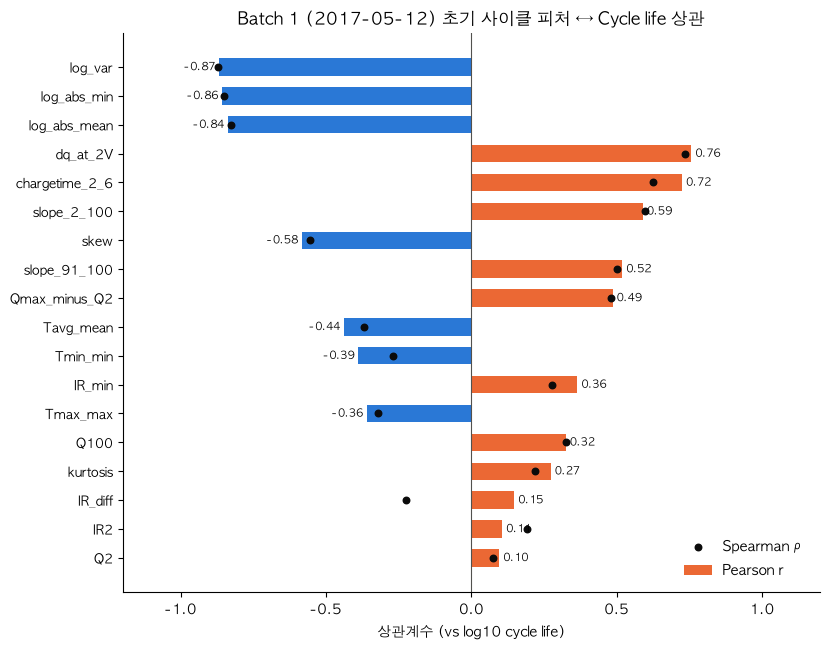

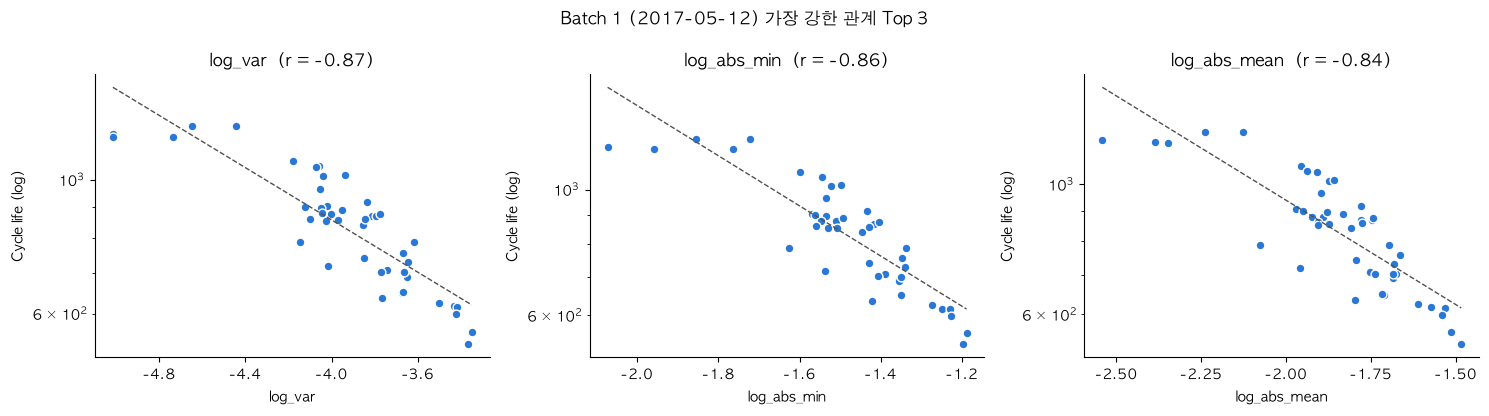

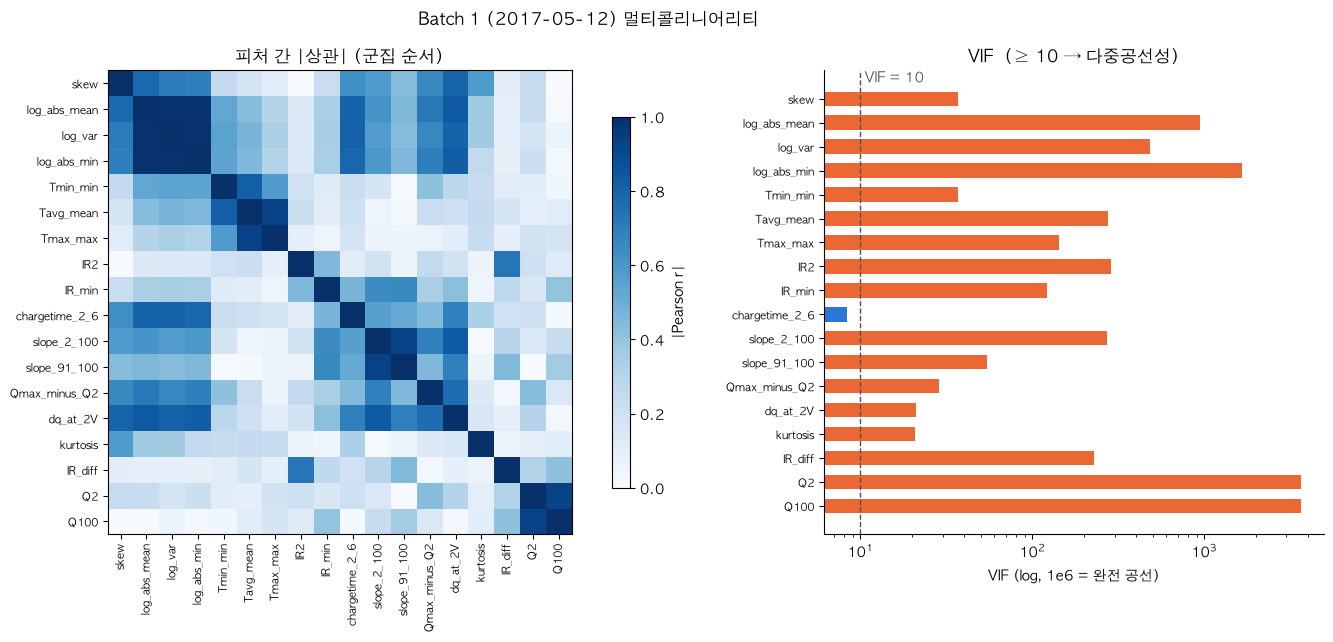

|r| ≥ 0.9 인 피처 쌍:
log_var       log_abs_min     0.992
log_abs_mean  log_abs_min     0.989
              log_var         0.989
Tavg_mean     Tmax_max        0.933
slope_2_100   slope_91_100    0.928
Q2            Q100            0.925 

VIF ≥ 10 피처: 17 / 18개
VIF 큰 순서로 제거 → 남은 11개 (모두 VIF < 10), 제거 순서: ['Q100', 'log_abs_min', 'Tavg_mean', 'log_abs_mean', 'IR2', 'slope_2_100', 'dq_at_2V']


,VIF,r (log life)
log_var,8.22,-0.868
chargetime_2_6,5.99,0.724
skew,5.31,-0.584
Qmax_minus_Q2,4.14,0.485
slope_91_100,3.46,0.518
Tmin_min,2.79,-0.390
IR_min,2.66,0.364
kurtosis,2.64,0.272
Q2,2.24,0.095
Tmax_max,1.83,-0.360


,pearson,spearman,VIF,kept
log_var,-0.868,-0.871,483.444,True
log_abs_min,-0.858,-0.850,1660.454,False
log_abs_mean,-0.838,-0.828,945.064,False
dq_at_2V,0.756,0.735,21.033,False
chargetime_2_6,0.724,0.624,8.303,True
slope_2_100,0.590,0.597,271.173,False
skew,-0.584,-0.556,36.674,True
slope_91_100,0.518,0.501,54.344,True
Qmax_minus_Q2,0.485,0.481,28.732,True
Tavg_mean,-0.438,-0.371,274.474,False


In [21]:
corr1 = eda_correlation(batch1, dqf1, "Batch 1 (2017-05-12)")
corr1.round(3)

## Batch 2 (2018-02-20)

분석 대상 39 / 47셀 (cycle_life 결측 제외), 피처 18개
  피처 결측 셀 6개 (예: IR이 전부 0으로 기록) → life 상관은 피처별로 가능한 셀만, VIF는 33셀로 계산


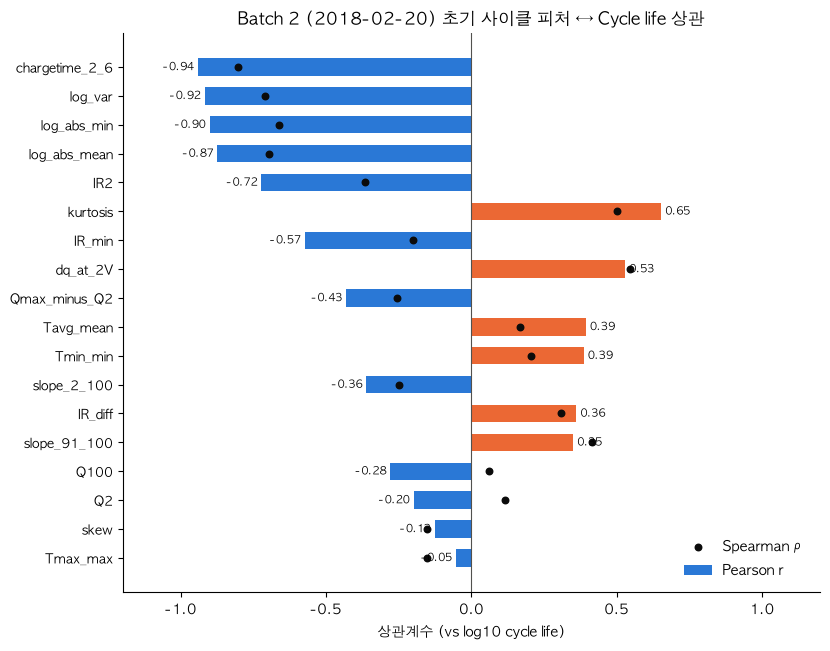

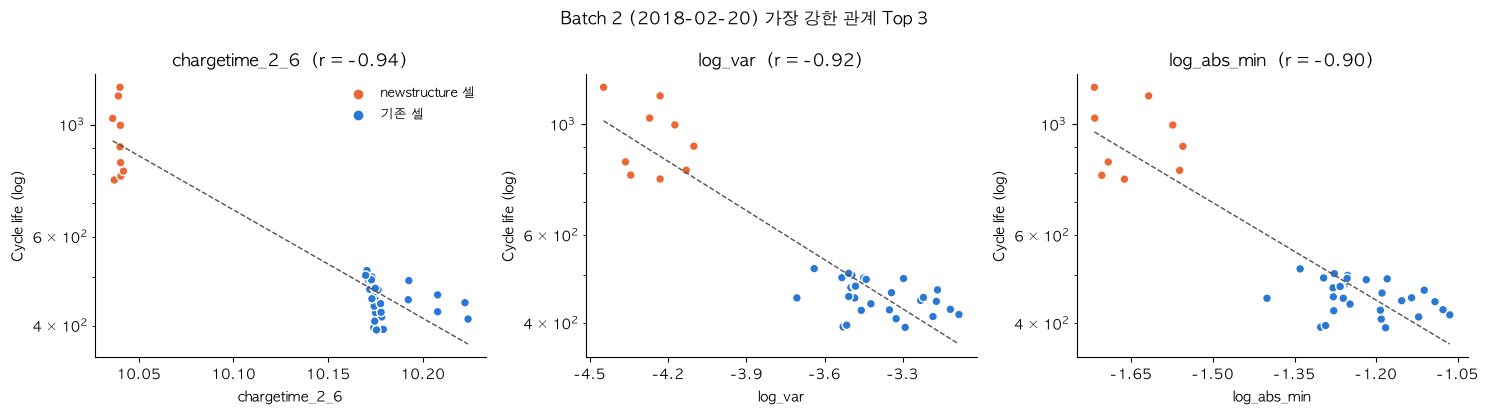

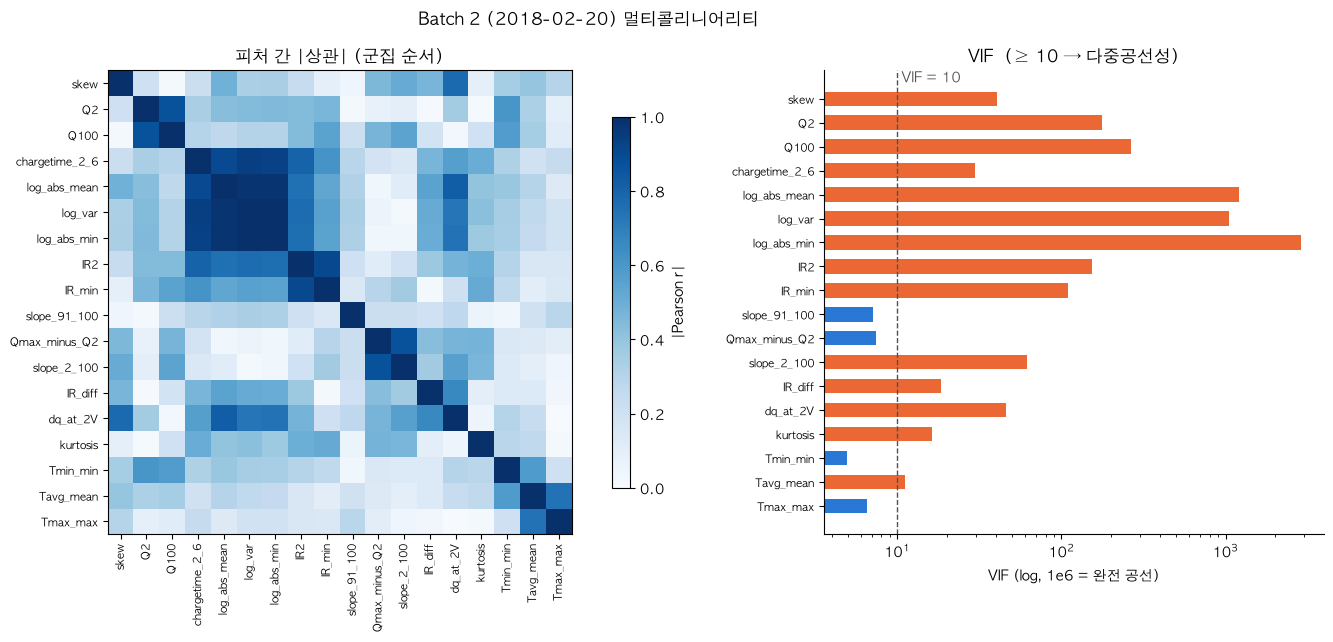

|r| ≥ 0.9 인 피처 쌍:
log_var         log_abs_min    0.997
log_abs_mean    log_abs_min    0.984
                log_var        0.981
chargetime_2_6  log_var        0.939
                log_abs_min    0.930
IR2             IR_min         0.906 

VIF ≥ 10 피처: 14 / 18개
VIF 큰 순서로 제거 → 남은 12개 (모두 VIF < 10), 제거 순서: ['log_abs_min', 'log_var', 'Q100', 'IR2', 'log_abs_mean', 'dq_at_2V']


,VIF,r (log life)
Qmax_minus_Q2,6.20,-0.431
Tavg_mean,6.05,0.393
slope_2_100,6.01,-0.362
Tmax_max,4.71,-0.053
chargetime_2_6,4.55,-0.942
IR_min,3.25,-0.574
Tmin_min,2.86,0.386
kurtosis,2.78,0.653
IR_diff,2.76,0.361
Q2,2.70,-0.199


,pearson,spearman,VIF,kept
chargetime_2_6,-0.942,-0.802,29.853,True
log_var,-0.918,-0.709,1054.627,False
log_abs_min,-0.901,-0.661,2875.595,False
log_abs_mean,-0.874,-0.697,1207.391,False
IR2,-0.723,-0.365,153.198,False
kurtosis,0.653,0.500,16.251,True
IR_min,-0.574,-0.200,109.008,True
dq_at_2V,0.529,0.545,46.170,False
Qmax_minus_Q2,-0.431,-0.257,7.457,True
Tavg_mean,0.393,0.166,11.179,True


In [22]:
corr2 = eda_correlation(batch2, dqf2, "Batch 2 (2018-02-20)")
corr2.round(3)

## Batch 3 (2018-04-12)

분석 대상 44 / 46셀 (cycle_life 결측 제외), 피처 18개


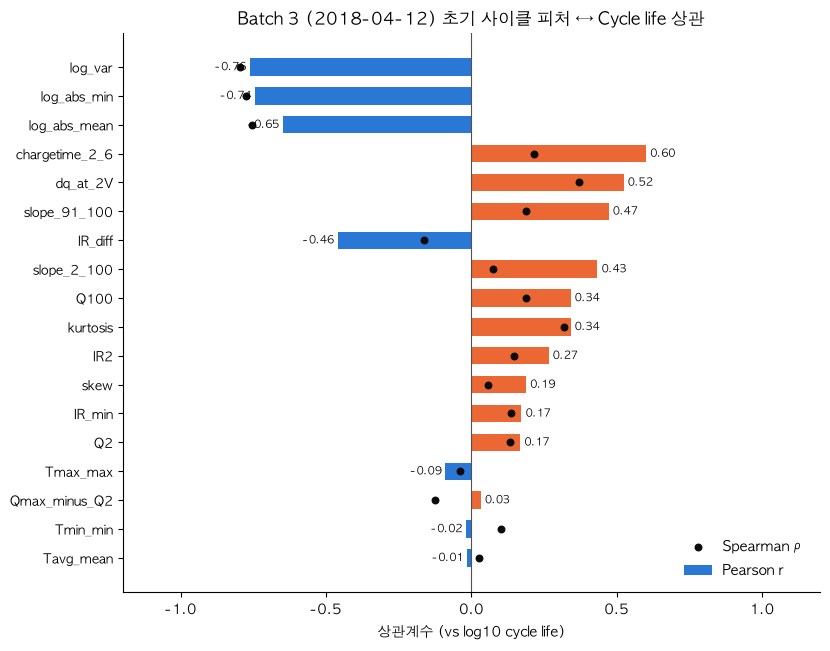

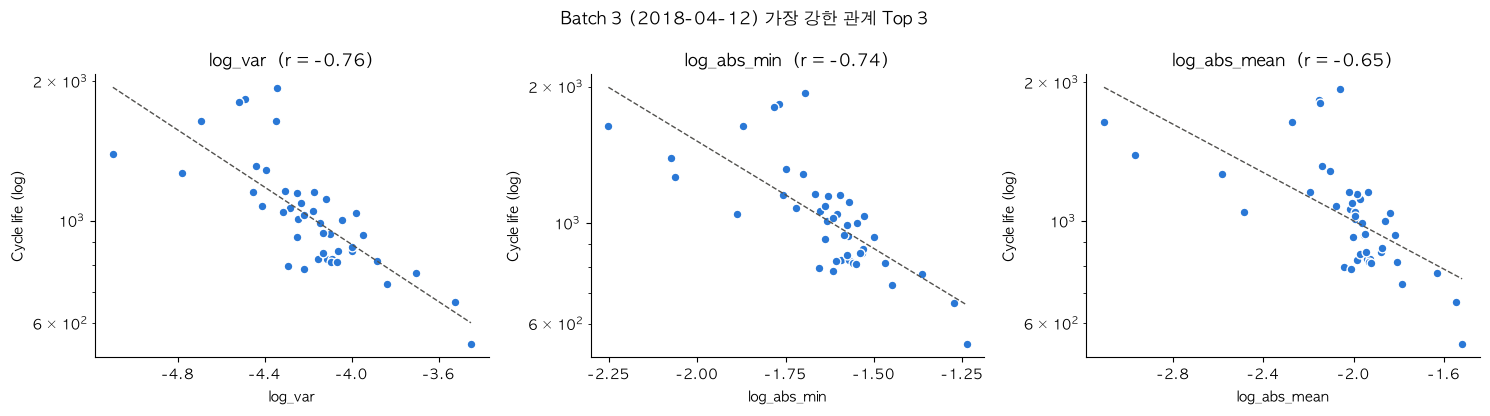

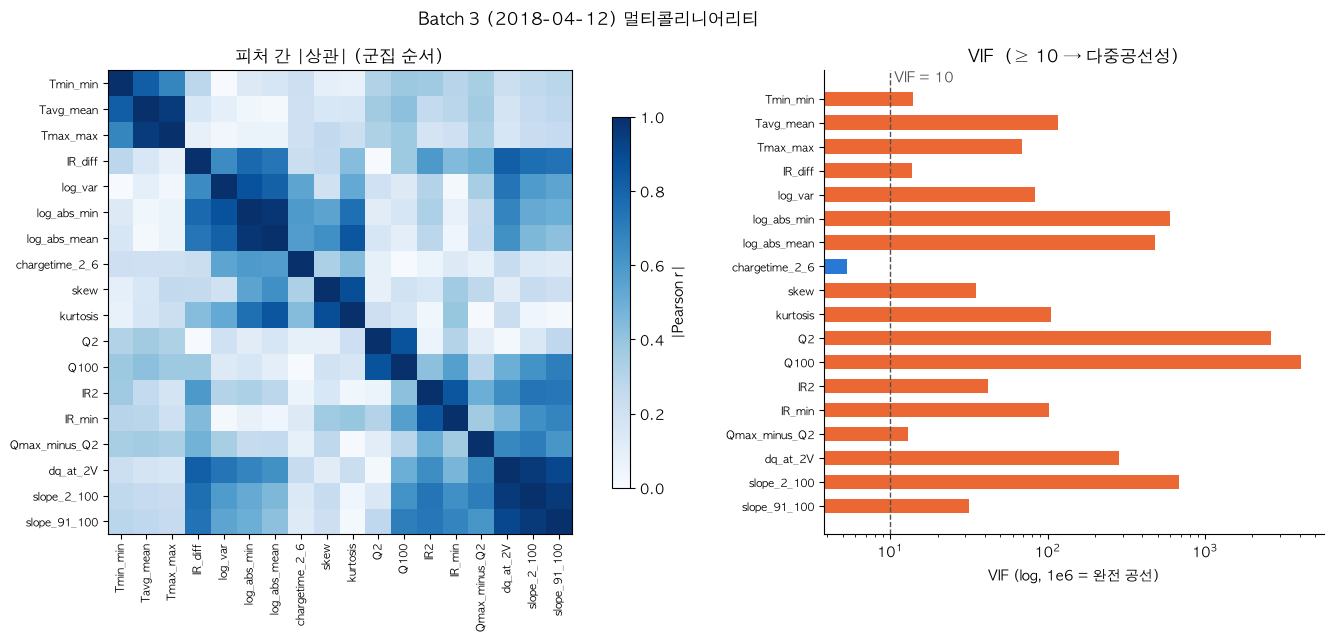

|r| ≥ 0.9 인 피처 쌍:
log_abs_min  log_abs_mean    0.974
slope_2_100  slope_91_100    0.963
dq_at_2V     slope_2_100     0.962
Tavg_mean    Tmax_max        0.956
dq_at_2V     slope_91_100    0.909 

VIF ≥ 10 피처: 17 / 18개
VIF 큰 순서로 제거 → 남은 10개 (모두 VIF < 10), 제거 순서: ['Q100', 'log_abs_min', 'dq_at_2V', 'Tavg_mean', 'kurtosis', 'slope_2_100', 'log_abs_mean', 'IR_min']


,VIF,r (log life)
slope_91_100,7.80,0.472
IR_diff,5.01,-0.460
log_var,3.47,-0.762
Tmin_min,2.86,-0.019
IR2,2.74,0.265
skew,2.73,0.188
Tmax_max,2.67,-0.090
Qmax_minus_Q2,2.26,0.032
Q2,2.12,0.168
chargetime_2_6,2.04,0.601


,pearson,spearman,VIF,kept
log_var,-0.762,-0.797,83.696,True
log_abs_min,-0.744,-0.776,597.780,False
log_abs_mean,-0.648,-0.756,480.248,False
chargetime_2_6,0.601,0.214,5.294,True
dq_at_2V,0.523,0.368,284.132,False
slope_91_100,0.472,0.188,31.630,True
IR_diff,-0.460,-0.163,13.801,True
slope_2_100,0.433,0.075,679.628,False
Q100,0.341,0.189,4067.650,False
kurtosis,0.341,0.320,105.681,False


In [23]:
corr3 = eda_correlation(batch3, dqf3, "Batch 3 (2018-04-12)")
corr3.round(3)

# 데이터 점검 - 결측치·이상치

EDA 1~5에서 쓴 `batch1~3`의 품질을 점검합니다. 여기서는 **확인만** 하고 원본 DataFrame은 바꾸지 않습니다. 실제 처리는 각 EDA 함수 안에서 했습니다 (`smooth_q`, `early_features` 등).

1. 결측치: 컬럼별 NaN 개수, `cycle_life`가 없는 셀, (cell_id, cycle) 중복·사이클 번호 누락
2. 이상치: 물리적으로 가능한 범위를 벗어난 값

이상치를 IQR이 아니라 **물리 범위**로 판단하는 이유가 있습니다. 용량(QDischarge)은 열화되면서 원래 계속 떨어지기 때문에, 분포 기준(IQR)으로 보면 정상적인 수명 말기 값까지 이상치로 잡힙니다.

In [24]:
batches = {"batch1": batch1, "batch2": batch2, "batch3": batch3}

# 1) 컬럼별 NaN 개수 (NaN이 하나라도 있는 컬럼만)
na = pd.DataFrame({name: df.isna().sum() for name, df in batches.items()})
print("컬럼별 NaN 개수")
display(na[na.sum(axis=1) > 0])

# 2) 셀 단위 점검: cycle_life 결측, (cell_id, cycle) 중복, 사이클 번호 누락
for name, df in batches.items():
    cells = df.groupby("cell_id").agg(
        policy=("policy", "first"),
        cycle_life=("cycle_life", "first"),
        n_cycles=("cycle", "max"),
        Q_last=("QDischarge", lambda s: s.iloc[-10:].median()),  # 마지막 10사이클 중앙값
    )
    n_dup = df.duplicated(["cell_id", "cycle"]).sum()
    span = df.groupby("cell_id")["cycle"].agg(lambda s: s.max() - s.min() + 1 - len(s))
    print(f"\n{name}: cycle_life 결측 {cells['cycle_life'].isna().sum()} / {len(cells)}셀"
          f" | 중복 행 {n_dup} | 사이클 번호 누락 셀 {(span != 0).sum()}")
    miss = cells[cells["cycle_life"].isna()]
    if len(miss):
        display(miss.round(3))

컬럼별 NaN 개수


,batch1,batch2,batch3
cycle_life,0,3870,4426



batch1: cycle_life 결측 0 / 46셀 | 중복 행 0 | 사이클 번호 누락 셀 0

batch2: cycle_life 결측 8 / 47셀 | 중복 행 0 | 사이클 번호 누락 셀 0


,policy,cycle_life,n_cycles,Q_last
cell_id,,,,
22,VarCharge-2C-100cycles,NaN,920.0,1.056
23,VarCharge-4C-100cycles,NaN,1152.0,0.980
35,VarCharge-6C-100cycles,NaN,423.0,0.886
36,VarCharge-8C-100cycles,NaN,280.0,0.886
37,3.6C(80%)-3.6C(SLOWCYCLE,NaN,101.0,1.085
38,4.8C(80%)-4.8C(SLOWCYCLE,NaN,101.0,1.082
39,3.6C(9%)-5C(SLOWCYCLE,NaN,434.0,0.890
40,5.2C(58%)-4C(SLOWCYCLE,NaN,459.0,0.889



batch3: cycle_life 결측 2 / 46셀 | 중복 행 0 | 사이클 번호 누락 셀 0


,policy,cycle_life,n_cycles,Q_last
cell_id,,,,
23,4.8C(80%)-4.8C-newstructure,NaN,2189.0,0.938
32,4.8C(80%)-4.8C-newstructure,NaN,2237.0,0.974


### 결측치 해석

- **batch1**: NaN이 하나도 없습니다.
- **batch2 / batch3**: NaN은 모두 `cycle_life` 컬럼에만 있고, 측정값(IR, Q, T, chargetime)에는 없습니다. 행 수가 많아 보이지만 셀로 세면 batch2는 8셀, batch3는 2셀입니다.
  - **batch2의 8셀은 일반 고속 충전 실험이 아닙니다.** `VarCharge`(22, 23, 35, 36)와 `SLOWCYCLE`(37~40)처럼 실험 조건이 다른 셀입니다. 그리고 `Q_last`가 모두 EOL 기준(0.88Ah, 공칭 1.1Ah의 80%)보다 높아서 수명이 정의되지 않았습니다. 37, 38은 101사이클만 측정됐습니다.
  - **batch3의 2셀**(23, 32)은 2,200사이클 넘게 돌렸는데도 `Q_last`가 0.94~0.97Ah입니다. 실험이 끝날 때까지 EOL에 도달하지 않은, **수명이 아주 긴 셀**입니다.
- 중복 행과 사이클 번호 누락은 세 배치 모두 없습니다.

➡️ **처리**: 수명을 다루는 분석(분포, 상관 등)에서는 `cycle_life` 결측 셀을 제외합니다. 수명은 예측 타깃이라 보간으로 채우면 안 되기 때문입니다. 다만 batch3의 2셀을 빼면 장수명 쪽이 조금 덜 반영된다는 점은 기억해 둡니다. 열화 곡선처럼 사이클 추이만 보는 분석에는 포함해도 됩니다.
  - EDA 2: 용량 곡선에는 회색으로 포함됩니다. 그리고 batch2의 35, 36, 39, 40은 마지막 용량이 0.886~0.89Ah로 EOL 판정 허용폭(+0.01) 안이라 "EOL 도달"로 분류됩니다. 그래서 열화 속도 요약 통계(`early_rate`, `late_rate`, `accel`)에 들어가 있습니다. 요약 통계의 "EOL 도달 셀 43 / 47" 중 4셀이 이 셀들입니다.
  - EDA 3: ΔQ(V) 곡선 그래프에는 회색으로 그려지고, 장·단수명 비교와 상관 계산에서는 빠집니다.


batch1  (전체 38,811행)


,첫 사이클,0값 (첫 사이클 제외),범위 밖 (0 제외),해당 셀 수
QDischarge,46,0,2,2
QCharge,46,0,27,2
IR,46,19,0,16
Tavg,46,0,0,0
Tmax,46,0,0,0
Tmin,46,0,0,0
chargetime,46,0,6,6



batch2  (전체 26,904행)


,첫 사이클,0값 (첫 사이클 제외),범위 밖 (0 제외),해당 셀 수
QDischarge,0,0,11,8
QCharge,0,0,11,8
IR,7,4897,0,7
Tavg,1,0,49,1
Tmax,1,0,100,1
Tmin,1,24,100,8
chargetime,0,0,22,18


  IR이 전부 0으로 기록된 셀: [40, 41, 42, 43, 44, 45, 46]

batch3  (전체 51,007행)


,첫 사이클,0값 (첫 사이클 제외),범위 밖 (0 제외),해당 셀 수
QDischarge,0,0,0,0
QCharge,0,0,0,0
IR,0,0,0,0
Tavg,0,0,0,0
Tmax,0,0,0,0
Tmin,0,0,0,0
chargetime,0,0,0,0


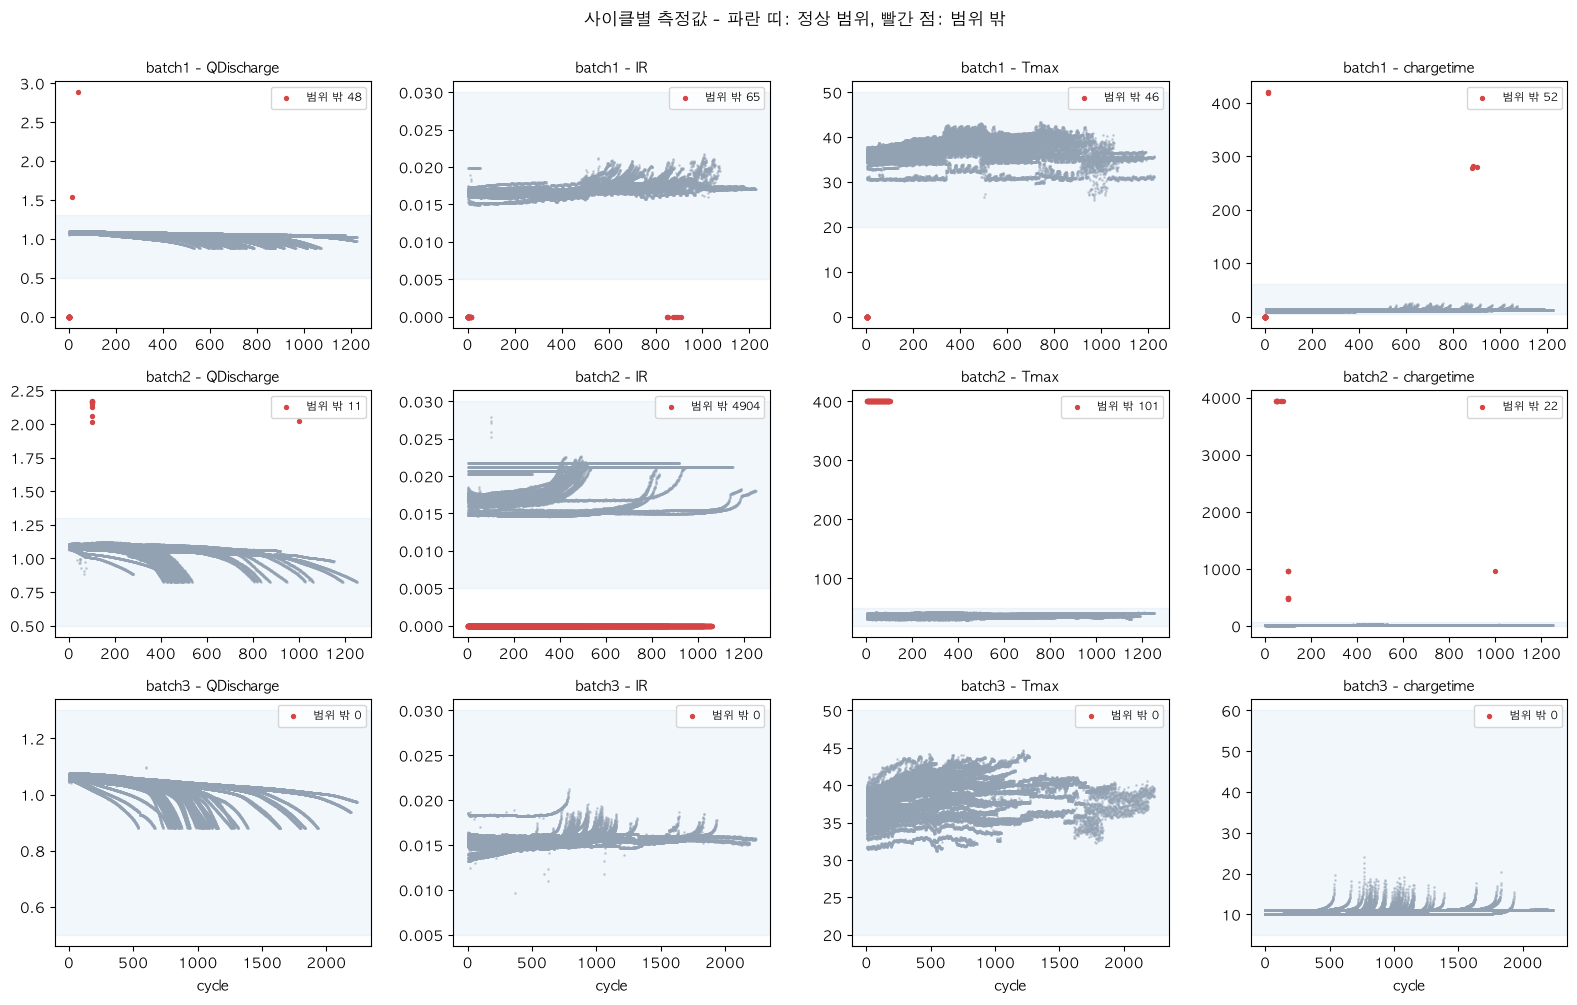

In [25]:
# 물리적으로 가능한 범위 - 공칭 용량 1.1Ah, 30°C 챔버, 고속 충전(약 10분) 실험 기준
VALID = {
    "QDischarge": (0.5, 1.3),
    "QCharge": (0.5, 1.3),
    "IR": (0.005, 0.03),     # Ω
    "Tavg": (20, 50),        # °C
    "Tmax": (20, 50),
    "Tmin": (20, 50),
    "chargetime": (5, 60),   # 분
}


def outlier_table(df):
    """컬럼별 범위 밖 값 개수 - 첫 사이클 / 0값 / 그 외 범위 밖으로 나눠서"""
    first = df["cycle"] == df.groupby("cell_id")["cycle"].transform("min")
    rows = {}
    for col, (lo, hi) in VALID.items():
        bad = ~df[col].between(lo, hi)
        zero = df[col] == 0
        rows[col] = {
            "첫 사이클": (bad & first).sum(),
            "0값 (첫 사이클 제외)": (zero & ~first).sum(),
            "범위 밖 (0 제외)": (bad & ~zero & ~first).sum(),
            "해당 셀 수": df.loc[bad & ~first, "cell_id"].nunique(),
        }
    return pd.DataFrame(rows).T


for name, df in batches.items():
    print(f"\n{name}  (전체 {len(df):,}행)")
    display(outlier_table(df))
    ir0 = df[df["cycle"] > 1].groupby("cell_id")["IR"].apply(lambda s: (s == 0).all())
    if ir0.any():
        print(f"  IR이 전부 0으로 기록된 셀: {ir0[ir0].index.tolist()}")

# 사이클별 산점도 - 범위 밖 값은 빨간 점
cols = ["QDischarge", "IR", "Tmax", "chargetime"]
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for r, (name, df) in enumerate(batches.items()):
    for c, col in enumerate(cols):
        ax = axes[r, c]
        lo, hi = VALID[col]
        bad = ~df[col].between(lo, hi)
        ax.scatter(df.loc[~bad, "cycle"], df.loc[~bad, col], s=1, color="#9aa5b1", alpha=0.4, rasterized=True)
        ax.scatter(df.loc[bad, "cycle"], df.loc[bad, col], s=8, color="#d64545", label=f"범위 밖 {bad.sum()}")
        ax.axhspan(lo, hi, color="#2a78d6", alpha=0.06)
        ax.set_title(f"{name} - {col}", fontsize=10)
        ax.legend(loc="upper right", fontsize=8)
        if r == 2:
            ax.set_xlabel("cycle")
fig.suptitle("사이클별 측정값 - 파란 띠: 정상 범위, 빨간 점: 범위 밖", y=1.0)
plt.tight_layout()
plt.show()

### 이상치 해석

| 배치 | 이상치 | 원인 추정 | 처리 |
|---|---|---|---|
| batch1 | **첫 사이클이 전 컬럼 0** (46셀 전부) | 사이클 1이 기록되지 않은 자리 채움 값 | 사이클 1 제외 |
| batch1 | IR = 0 (16셀, 19행), QDischarge 1.5~2.9Ah 스파이크 (2셀), chargetime 280~420분 (6셀) | 측정 누락 / 사이클 경계가 잘못 잘린 값 | IR은 0 제외, Q는 범위 필터와 rolling median. chargetime은 이상치가 사이클 13 이후에 있어서, 사이클 2~6만 쓰는 `chargetime_2_6`에 영향 없음 |
| batch2 | **IR이 전부 0인 셀 7개** (40~46, 약 4,900행) | IR 측정이 아예 안 된 셀 | IR 피처 계산에서 해당 셀 제외 (NaN 처리) |
| batch2 | 셀 38의 Tmax = 400°C (초기 100사이클), Tavg·Tmin 음수 | 온도 센서 이상 (400은 센서 상한값으로 보임) | EDA 5: 온도 3개 모두 20~50°C 범위 밖 값 제외 (`early_features`). EDA 4: `Tmax > 0`만 거르지만, 셀 38은 `cycle_life` 결측이라 이미 빠져서 영향 없음 |
| batch2 | QDischarge 2.0~2.2Ah (8셀, 11행), chargetime 500~3,900분 (18셀, 22행) | 실험 중단이나 재시작 지점의 기록 오류 | Q: 범위 필터 (`smooth_q`). chargetime: 따로 거르지 않음. 이상치가 사이클 48 이후에 있어서, 사이클 2~6만 쓰는 `chargetime_2_6`에 영향 없음 |
| batch3 | **없음** | - | - |

- 이상치는 대부분 **물리적으로 불가능한 값**이라서(용량 1.1Ah 셀이 2Ah를 방전, 400°C 등) 셀 특성이 아니라 기록 오류로 봅니다. 그래서 제거해도 정보 손실이 없습니다.
- 반대로 수명 말기의 용량 급락, IR 상승, chargetime이 15~25분으로 늘어나는 것은 **실제 열화 현상**입니다. 범위 안에 있으므로 이상치로 처리하지 않습니다.
- batch2가 가장 지저분하고 batch3가 가장 깨끗합니다. 그래서 batch2의 상관·피처 결과는 해석할 때 조심합니다 (EDA 5에서 IR 피처 결측 6셀 제외).
- EDA 5의 `Tmin_min`은 처음에 `Tavg > 0`으로만 걸러서, batch2 셀 41·46의 Tmin = 0 행이 그대로 최솟값으로 잡혔습니다. 지금은 온도 3개 모두 20~50°C 범위 밖 값을 빼고 계산합니다.
- 이 섹션은 `summary`만 점검했습니다. EDA 3의 ΔQ(V)는 `cycles`의 `Qdlin`(사이클 10, 100)으로 계산하는데, 이 데이터는 따로 점검하지 않았습니다. batch2의 Q 스파이크가 사이클 99~101에 몰려 있지만, 해당 셀(22, 23, 35~40)은 모두 `cycle_life` 결측이라 ΔQ 상관 계산에서는 빠집니다.

# 모델 설계 전략

EDA 1~5와 데이터 점검 결과를 바탕으로 모델을 설계합니다.

1. **Feature Engineering**: EDA에서 확인한 내용으로 유의미한 변수 선별
2. **Regression vs Classification**: 하나를 고르고, 그에 맞는 Target Variable 정의
3. **Modeling Strategy**: 데이터 처리, 검증 방식, 후보 모델

EDA는 배치별로 봤지만 여기부터는 세 배치를 **합쳐서** 봅니다. 모델은 세 배치를 함께 학습하므로, 배치마다 다르게 움직이는 피처를 걸러내야 하기 때문입니다.

## 1. Feature Engineering - 유의미한 변수 선별

후보는 EDA 5의 18개 피처(`summary` 12개 + ΔQ 6개)와 EDA 4의 충전 정책 변수(C1, Q1, C2, newstructure)입니다. 아래 세 기준으로 거릅니다.

1. **누수 금지**: 초기 100사이클 안에서 계산되는 값만 씁니다. EDA 2의 `knee_frac`, `late_rate`, `accel`은 수명 말기까지 봐야 알 수 있어서 후보에서 뺍니다. 충전 정책은 실험 전에 정해지는 값이라 써도 됩니다.
2. **배치 일관성**: 세 배치 모두에서 log10(cycle life)와의 상관 부호가 같고, 가장 약한 배치에서도 |r| ≥ 0.15여야 합니다. EDA 5에서 `chargetime_2_6`, IR, 온도는 배치마다 부호가 바뀌었습니다. 이런 피처는 배치를 합치면 상관이 커 보여도 수명이 아니라 배치 차이(셀 구조, 실험 시기)를 담고 있을 수 있습니다.
3. **중복 제거**: 남은 피처끼리 |r| ≥ 0.7이면 합친 데이터에서 |r|이 큰 쪽 하나만 남깁니다. EDA 5에서 `log_var`, `log_abs_min`, `log_abs_mean`은 서로 r ≥ 0.97이었습니다.

모델링 대상 129 / 139셀, 후보 피처 22개 | {'batch1': 46, 'batch2': 39, 'batch3': 44}


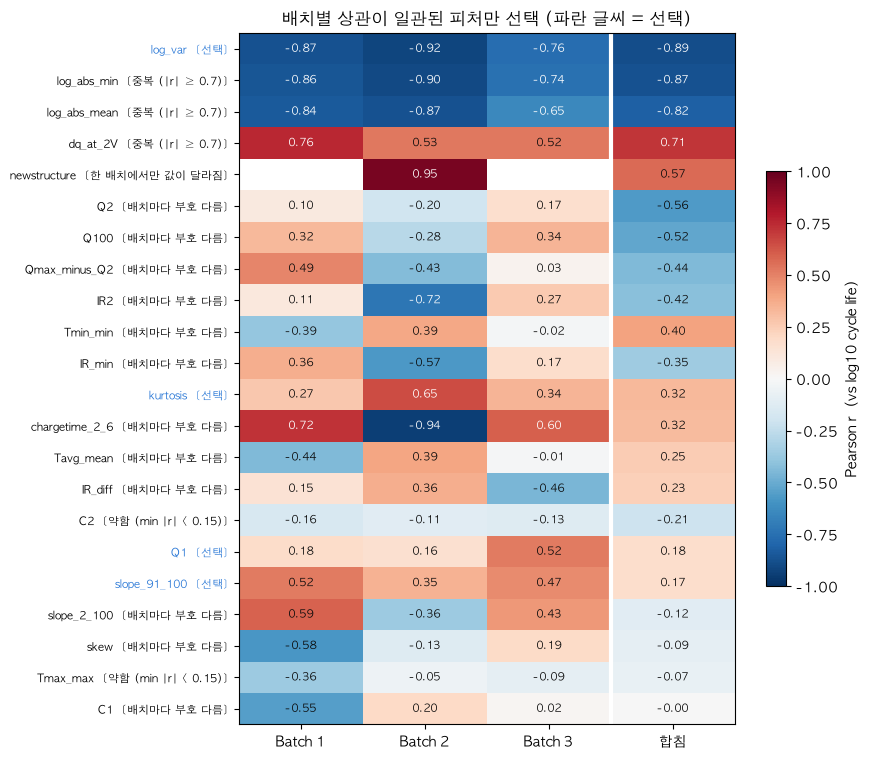

선택된 피처 4개: ['log_var', 'kurtosis', 'Q1', 'slope_91_100']


,batch1,batch2,batch3,pooled,min_abs_r,status
log_var,-0.87,-0.92,-0.76,-0.89,0.76,선택
log_abs_min,-0.86,-0.90,-0.74,-0.87,0.74,중복 (|r| ≥ 0.7)
log_abs_mean,-0.84,-0.87,-0.65,-0.82,0.65,중복 (|r| ≥ 0.7)
dq_at_2V,0.76,0.53,0.52,0.71,0.52,중복 (|r| ≥ 0.7)
newstructure,NaN,0.95,NaN,0.57,0.95,한 배치에서만 값이 달라짐
Q2,0.10,-0.20,0.17,-0.56,0.10,배치마다 부호 다름
Q100,0.32,-0.28,0.34,-0.52,0.28,배치마다 부호 다름
Qmax_minus_Q2,0.49,-0.43,0.03,-0.44,0.03,배치마다 부호 다름
IR2,0.11,-0.72,0.27,-0.42,0.11,배치마다 부호 다름
Tmin_min,-0.39,0.39,-0.02,0.40,0.02,배치마다 부호 다름


In [26]:
dqfs = {"batch1": dqf1, "batch2": dqf2, "batch3": dqf3}


def cell_dataset(df, dqf, name):
    """배치 → 셀 단위 모델링 테이블: 충전 정책(EDA 4) + 초기 100사이클 피처(EDA 5) + ΔQ 피처(EDA 3)"""
    cells = df.groupby("cell_id").agg(policy=("policy", "first"), cycle_life=("cycle_life", "first"))
    cells = cells.join(cells["policy"].apply(parse_policy))
    cells["newstructure"] = cells["policy"].str.contains("newstructure").astype(int)
    out = cells.join(early_features(df)).join(dqf.drop(columns="cycle_life"))
    out.insert(0, "batch", name)
    out.index = name + "_" + out.index.astype(str)
    return out


data_all = pd.concat([cell_dataset(df, dqfs[name], name) for name, df in batches.items()])
data = data_all[data_all["cycle_life"].notna()].copy()  # cycle_life 결측 10셀 제외 (데이터 점검 참고)
FEATURES = data.columns.drop(["batch", "policy", "cycle_life"]).tolist()
y_log = np.log10(data["cycle_life"])
print(f"모델링 대상 {len(data)} / {len(data_all)}셀, 후보 피처 {len(FEATURES)}개 |",
      data["batch"].value_counts().sort_index().to_dict())

# 1) 배치별 / 합친 데이터의 log10(cycle life) 상관. 배치 안에서 값이 하나뿐인 피처(newstructure)는 NaN
names = list(batches)
r = {}
for n in names:
    sub = data.loc[data["batch"] == n, FEATURES]
    r[n] = sub.loc[:, sub.nunique() > 1].corrwith(y_log[data["batch"] == n]).reindex(FEATURES)
r = pd.DataFrame(r)
r["pooled"] = data[FEATURES].corrwith(y_log)
r["sign_same"] = r[names].notna().all(axis=1) & np.sign(r[names]).nunique(axis=1).eq(1)
r["min_abs_r"] = r[names].abs().min(axis=1)
r = r.sort_values("pooled", key=abs, ascending=False)

# 2) 기준 2(배치 일관성) 통과 → pooled |r| 큰 순서로 기준 3(중복 제거)
SELECTED = []
for f in r.index[r["sign_same"] & (r["min_abs_r"] >= 0.15)]:
    if all(abs(data[f].corr(data[s])) < 0.7 for s in SELECTED):
        SELECTED.append(f)


def status(f):
    if f in SELECTED:
        return "선택"
    if r.loc[f, names].isna().any():
        return "한 배치에서만 값이 달라짐"
    if not r.at[f, "sign_same"]:
        return "배치마다 부호 다름"
    if r.at[f, "min_abs_r"] < 0.15:
        return "약함 (min |r| < 0.15)"
    return "중복 (|r| ≥ 0.7)"


r["status"] = [status(f) for f in r.index]

# 3) 히트맵: 행 = 피처(합친 데이터 |r| 순), 열 = 배치 + 합친 데이터
cols = names + ["pooled"]
fig, ax = plt.subplots(figsize=(8, 0.34 * len(r) + 1.5))
im = ax.imshow(r[cols].astype(float), cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
for i, f in enumerate(r.index):
    for j, c in enumerate(cols):
        v = r.at[f, c]
        if v == v:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if abs(v) > 0.6 else "#0b0b0b")
ax.set_xticks(range(len(cols)), ["Batch 1", "Batch 2", "Batch 3", "합침"])
ax.set_yticks(range(len(r)), [f"{f}  [{s}]" for f, s in zip(r.index, r["status"])], fontsize=8)
for lab, s in zip(ax.get_yticklabels(), r["status"]):
    if s == "선택":
        lab.set_color("#2a78d6")
ax.axvline(2.5, color="white", linewidth=3)
fig.colorbar(im, ax=ax, label="Pearson r  (vs log10 cycle life)", shrink=0.6)
ax.set_title("배치별 상관이 일관된 피처만 선택 (파란 글씨 = 선택)")
plt.show()

print(f"선택된 피처 {len(SELECTED)}개: {SELECTED}")
display(r[cols + ["min_abs_r", "status"]].round(2))

선택 피처 결측 셀 수: {'log_var': 0, 'kurtosis': 0, 'Q1': 0, 'slope_91_100': 0}


,VIF,r (합침)
log_var,1.29,-0.89
kurtosis,1.19,0.32
Q1,1.05,0.18
slope_91_100,1.06,0.17


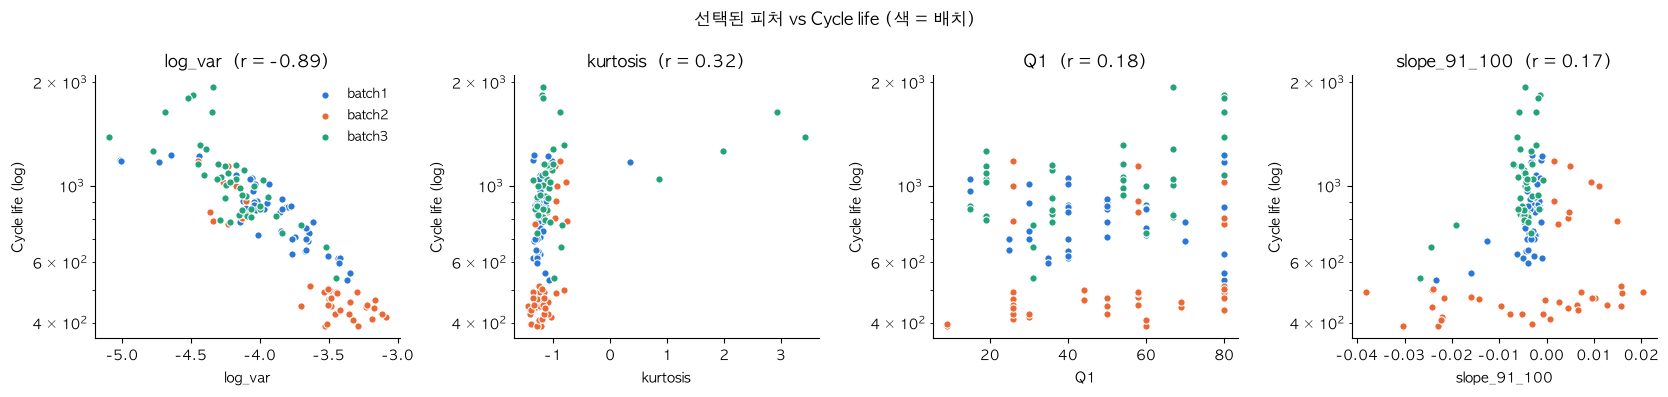

In [27]:
# 선택된 피처: 결측 / 다중공선성(VIF, EDA 5의 vif 함수) 확인
print("선택 피처 결측 셀 수:", data[SELECTED].isna().sum().to_dict())
display(pd.DataFrame({"VIF": vif(data[SELECTED]), "r (합침)": r.loc[SELECTED, "pooled"]}).round(2))

# 선택 피처 vs cycle life - 배치별 색으로 보면 배치 안 추세가 같은 방향인지 보입니다
BATCH_COLORS = {"batch1": "#2a78d6", "batch2": "#eb6834", "batch3": "#22a37a"}
fig, axes = plt.subplots(1, len(SELECTED), figsize=(4.2 * len(SELECTED), 4))
for ax, f in zip(np.atleast_1d(axes), SELECTED):
    for n, color in BATCH_COLORS.items():
        m = data["batch"] == n
        ax.scatter(data.loc[m, f], data.loc[m, "cycle_life"], s=28, color=color, edgecolor="white",
                   linewidth=0.8, label=n)
    ax.set_yscale("log")
    ax.set(xlabel=f, ylabel="Cycle life (log)", title=f"{f}  (r = {r.at[f, 'pooled']:.2f})")
    ax.spines[["top", "right"]].set_visible(False)
np.atleast_1d(axes)[0].legend(frameon=False, fontsize=9)
fig.suptitle("선택된 피처 vs Cycle life (색 = 배치)", fontweight="bold")
plt.tight_layout()
plt.show()

### 피처 선별 결과

| 피처 | 근거 (EDA) | 판단 |
|---|---|---|
| `log_var` | EDA 3·5: 세 배치 모두 가장 강한 피처 (r = −0.87 / −0.92 / −0.76) | **핵심 피처** |
| `slope_91_100` | EDA 5: 초기 용량 감소 기울기, 세 배치 모두 양의 상관 (0.35 ~ 0.52) | 선택 |
| `kurtosis` | EDA 3: ΔQ 곡선 모양, 세 배치 모두 양의 상관 (0.27 ~ 0.65) | 선택 |
| `Q1` | EDA 4: 충전 전환 SOC. 실험 전에 정해지는 값. 상관은 약한 편 (0.16 ~ 0.52) | 선택 (경계선) |
| `log_abs_min`, `log_abs_mean`, `dq_at_2V` | `log_var`와 \|r\| ≥ 0.7 | 중복이라 제외 |
| `chargetime_2_6`, `Q2`, `Q100`, `Qmax_minus_Q2`, IR, `Tavg_mean`, `Tmin_min`, `slope_2_100`, `skew`, `C1` | 배치마다 부호가 다름. 예: `chargetime_2_6`은 +0.72 / −0.94 / +0.60, `Q2`는 배치 안에서 약한데(≤ 0.2) 합치면 −0.56 | 배치 차이를 담은 피처라 제외 |
| `C2`, `Tmax_max` | 세 배치 모두 부호는 같지만 가장 약한 배치에서 \|r\| < 0.15 (`C2` 0.11, `Tmax_max` 0.05) | 약해서 제외 |
| `newstructure` | Batch 2 안에서만 값이 달라짐 (Batch 1은 전부 기존, Batch 3은 전부 newstructure) → 배치와 섞여서 효과를 따로 볼 수 없음 | 제외 |
| `knee_frac`, `late_rate`, `accel` | EDA 2: 수명 말기를 봐야 계산 가능 | 누수라서 후보에서 제외 |

- 선택한 4개 피처의 VIF는 모두 1.3 이하입니다. EDA 5에서 문제였던 다중공선성이 해결됐습니다.
- IR 피처를 빼면서 Batch 2의 IR 결측(7셀) 문제도 함께 사라졌습니다. 선택 피처에는 결측이 없습니다.
- `Q2`처럼 **배치를 합쳤을 때만 상관이 커지는 피처**는 모델이 "이 셀이 어느 배치인가"를 맞히는 데 쓰게 됩니다. 새 배치(새 실험 조건)에서는 통하지 않기 때문에 뺐습니다.

## 2. Regression vs Classification → **Regression**, Target = `log10(cycle_life)`

| | Regression | Classification (예: < 500 / 500~1000 / > 1000) |
|---|---|---|
| 타깃 정보 | 392 ~ 1,935 사이클의 연속값을 그대로 사용 | 구간 경계에서 정보 손실. 셀 129개라 더 아까움 |
| EDA 근거 | EDA 3·5에서 피처가 log10(cycle life)와 **선형**으로 강하게 연관 (`log_var` r ≈ −0.89) | 클래스 비율이 배치마다 완전히 다름 (아래 표). 단수명 셀은 거의 Batch 2에만 있음 |
| 활용 | 예측값에 기준을 적용하면 분류도 가능 | 반대(분류 → 수명값)는 불가능 |

Target은 `cycle_life`가 아니라 **`log10(cycle_life)`** 입니다.
- `cycle_life`는 오른쪽 꼬리가 긴 분포입니다 (skew 0.89, Batch 3에 1,800 이상 셀). log를 취하면 skew가 −0.09로 대칭에 가까워집니다. 다만 Batch 2(단수명)가 따로 뭉쳐 있는 모양은 log 후에도 남습니다 → 3절의 배치별 검증으로 확인합니다.
- EDA 3·5의 상관 분석을 모두 log10 기준으로 했고, 그 기준에서 선형 관계가 확인됐습니다.
- 오차가 "몇 사이클"보다 "몇 %"에 가깝게 맞춰집니다. 수명 400 셀의 100 사이클 오차와 1,500 셀의 100 사이클 오차는 의미가 다르기 때문입니다.
- 평가는 예측값을 `10 ** ŷ`로 되돌려서 원래 사이클 단위로 합니다.

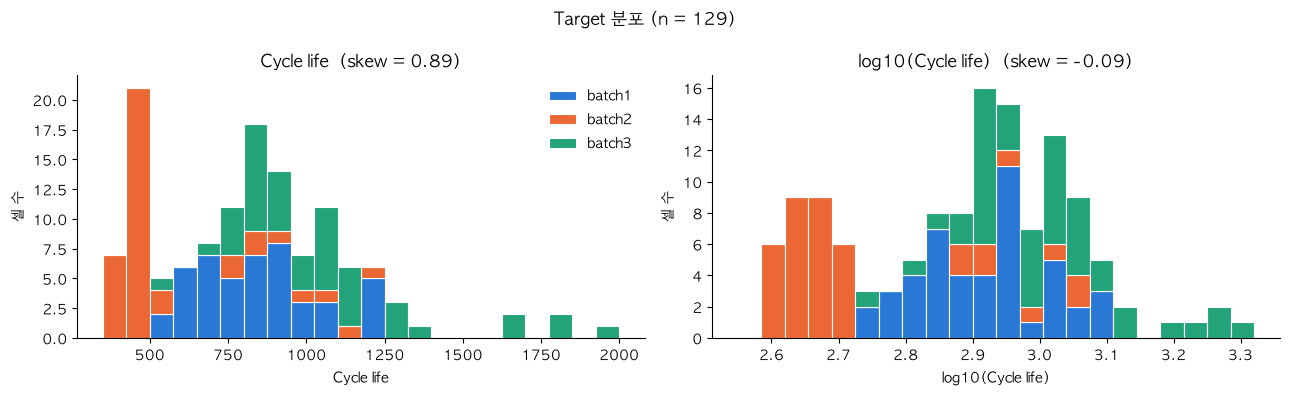

cycle_life,단수명(<500),중간(500~1000),장수명(≥1000),합계
batch,,,,
batch1,0,36,10,46
batch2,28,8,3,39
batch3,0,21,23,44
합계,28,65,36,129


In [28]:
# 타깃 분포: 원래 값 vs log10 (배치별로 쌓아서)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
for ax, vals, bins, label in [
    (ax1, data["cycle_life"], np.arange(350, 2001, 75), "Cycle life"),
    (ax2, y_log, np.linspace(2.55, 3.32, 23), "log10(Cycle life)"),
]:
    ax.hist([vals[data["batch"] == n] for n in BATCH_COLORS], bins=bins, stacked=True,
            color=list(BATCH_COLORS.values()), edgecolor="white", linewidth=0.8, label=list(BATCH_COLORS))
    ax.set(xlabel=label, ylabel="셀 수", title=f"{label}  (skew = {stats.skew(vals):.2f})")
    ax.spines[["top", "right"]].set_visible(False)
ax1.legend(frameon=False)
fig.suptitle(f"Target 분포 (n = {len(data)})", fontweight="bold")
plt.tight_layout()
plt.show()

# 분류로 나눴다면: 배치별 클래스 비율
cls = pd.cut(data["cycle_life"], [0, SHORT, LONG, np.inf], right=False,
             labels=[f"단수명(<{SHORT})", f"중간({SHORT}~{LONG})", f"장수명(≥{LONG})"])
display(pd.crosstab(data["batch"], cls, margins=True, margins_name="합계"))

## 3. Modeling Strategy

### 3-1. 데이터 처리

| 항목 | 방법 | 근거 |
|---|---|---|
| 샘플 단위 | 셀 1개 = 샘플 1개, **129셀** | `cycle_life` 결측 10셀 제외 (Batch 2 VarCharge·SLOWCYCLE 8셀, Batch 3 EOL 미도달 2셀). 타깃이라 보간하지 않음 |
| 입력 범위 | **초기 100사이클(2 ~ 100)** 데이터만 | 조기 예측이 목적. 수명 말기 정보를 쓰면 누수 |
| 이상치 | 기존 함수 그대로 (`smooth_q`, `early_features`) | 데이터 점검: 사이클 1 제외, 물리 범위 밖 값 제거, rolling median |
| 결측 | 선택 피처에는 없음. 피처를 추가해 결측이 생기면 Pipeline 안에서 median 대체 | IR 결측 셀(Batch 2)은 IR 피처를 빼면서 해결 |
| 스케일링 | `StandardScaler`를 **Pipeline 안에서** fold마다 fit | 검증 데이터의 평균·분산이 학습에 섞이지 않게 |
| 타깃 변환 | `log10(cycle_life)`로 학습 → `10 ** ŷ`로 되돌려 평가 | 2절 |

### 3-2. 검증 방식

- **주 검증: 충전 정책 단위 GroupKFold (5-fold)**. 같은 충전 조건의 셀이 많게는 16개씩 있습니다. 같은 조건의 셀이 학습과 검증에 나뉘어 들어가면, 모델이 정책을 외운 것이 성능으로 잡힙니다. `-newstructure` 표기를 떼고 같은 충전 조건이면 같은 그룹으로 묶습니다 (37개 그룹, 그룹당 1~16셀).
- **보조 검증: 배치 단위 Leave-One-Batch-Out (3-fold)**. 배치마다 수명 수준이 크게 다릅니다 (중앙값 858 / 472 / 1,006, EDA 1). 처음 보는 배치에서 얼마나 무너지는지 확인합니다.
- 하이퍼파라미터는 학습 fold 안에서 한 번 더 나누어 고릅니다 (nested CV). 셀이 129개뿐이라 별도 test set을 떼어두면 학습 데이터가 너무 적어지기 때문입니다.
- **지표**: RMSE(사이클), MAPE(%), 배치별 오차. 원래 사이클 단위로 계산합니다.

### 3-3. 후보 모델

| 단계 | 모델 | 선정 이유 (데이터 특성) |
|---|---|---|
| 0. 기준선 | 평균 예측, `log_var` 단일 선형회귀 | `log_var` 하나로 r ≈ −0.89. 모든 모델은 이 기준선보다 나아야 의미가 있음 |
| 1. 주력 | **ElasticNet** (선형 + L1/L2) | 샘플이 적고(129) 피처와 log 수명이 선형 관계. L1이 약한 피처(`Q1` 등)를 자동으로 0으로 만들어 1절의 선별을 한 번 더 검증. 계수로 해석 가능 |
| 2. 비선형 | **Gaussian Process Regression** | 소표본에 적합하고, 예측마다 불확실성(표준편차)을 함께 제공. 피처와 log 수명 사이의 완만한 비선형 관계 반영 |
| 3. 비선형 | **Random Forest / Gradient Boosting** (얕은 트리) | 피처 간 상호작용(예: 충전 조건 `Q1` × 열화 신호 `log_var`) 포착. 과적합 위험이 커서 `max_depth`, `min_samples_leaf`로 강하게 제한. 트리는 학습 범위 밖 값을 예측하지 못해 배치 외삽에 약함 → LOBO에서 확인 |

### 3-4. 기준선 성능 (사이클 단위)

In [29]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# 검증 그룹: 충전 정책('-newstructure' 표기 제거) / 배치
protocol = data["policy"].str.replace("-newstructure", "", regex=False)
CV_SCHEMES = {
    "정책 GroupKFold(5)": (GroupKFold(5), protocol),
    "Leave-One-Batch-Out": (GroupKFold(3), data["batch"]),
}
print(f"정책 그룹 {protocol.nunique()}개 (그룹당 셀 {protocol.value_counts().min()} ~ {protocol.value_counts().max()}개)")


def evaluate(model, cols):
    """log10 타깃으로 CV 예측 → 사이클 단위로 되돌려 RMSE / MAPE"""
    out = {}
    for scheme, (cv, groups) in CV_SCHEMES.items():
        pred = 10 ** cross_val_predict(model, data[cols], y_log, groups=groups, cv=cv)
        err = pred - data["cycle_life"]
        out[(scheme, "RMSE")] = np.sqrt((err ** 2).mean())
        out[(scheme, "MAPE %")] = 100 * (err.abs() / data["cycle_life"]).mean()
    return out


baseline = pd.DataFrame({
    "평균 예측": evaluate(DummyRegressor(), SELECTED),
    "log_var 선형": evaluate(make_pipeline(StandardScaler(), LinearRegression()), ["log_var"]),
    f"선택 {len(SELECTED)}개 선형": evaluate(make_pipeline(StandardScaler(), LinearRegression()), SELECTED),
}).T
print("기준선 성능 (사이클 단위)")
display(baseline.round(1))

정책 그룹 37개 (그룹당 셀 1 ~ 16개)
기준선 성능 (사이클 단위)


정책 GroupKFold(5)        Leave-One-Batch-Out       
                       RMSE MAPE %                RMSE MAPE %
평균 예측                 328.8   34.2               386.7   42.5
log_var 선형            195.1   14.0               221.0   20.1
선택 4개 선형              199.9   14.3               237.3   21.4

### 3-5. 주의할 점

- **Batch 2의 셀 구조 혼합**: 기존 셀과 newstructure 셀(수명 약 2배)이 섞여 있습니다. 배치별 오차를 따로 보고, Batch 2에서 오차가 구조별로 다른지 확인합니다.
- **장수명 쪽 과소 예측 가능성**: Batch 3의 EOL 미도달 2셀(2,200사이클 이상)이 빠져 있어, 가장 긴 수명대의 학습 데이터가 부족합니다.
- **선택 피처는 확정이 아닙니다**: 위 기준선에서 보듯 선형 모델에서는 `log_var` 하나와 4개 피처의 성능이 비슷합니다. 보조 피처 3개가 쓸모 있는지는 ElasticNet 계수와 비선형 모델 비교로 판단합니다.

### 정리

- **Target**: `log10(cycle_life)` 회귀. 평가는 사이클 단위 RMSE / MAPE.
- **피처**: `log_var` (핵심) + `slope_91_100`, `kurtosis`, `Q1` (보조). 모두 초기 100사이클 또는 실험 전에 알 수 있는 값입니다.
- **기준선**: `log_var` 하나만 써도 평균 예측보다 오차가 크게 줄어듭니다 (RMSE 329 → 195). 그래서 다음 단계 모델의 목표는 이 단일 피처 선형회귀를 넘는 것입니다.
- **다음 단계**: 정책 GroupKFold로 ElasticNet → GPR → 트리 모델 순서로 비교하고, LOBO로 배치가 바뀌어도 성능이 유지되는지 확인합니다.